Fetching data from wandb...
Saved to wandb_summary.csv
Number of valid runs: 92

===== Average performance (sorted by val/loss) =====
          run_name  val/loss  training_time_sec
G1_ternary_weights  1.473909         863.200000
    F1_context_128  1.499396         374.800000
         C1_1_head  1.522739         958.666667
A1_no_pos_encoding  1.568687         932.166667
        B2_post_ln  1.572513         899.333333
           D1_relu  1.609337         867.000000
E1_scaled_residual  1.688372         914.833333
        B1_rmsnorm  1.691348        1121.166667
          baseline  1.697955         893.000000
        C2_8_heads  1.710216         932.833333
       C3_12_heads  1.718171         938.000000
           A2_rope  1.743208        1060.833333
          A3_alibi  1.813131        1617.666667
         D2_swiglu  1.880832         981.833333
    F2_context_512  2.013404        1706.200000
   E2_no_residuals  3.357833         743.800000


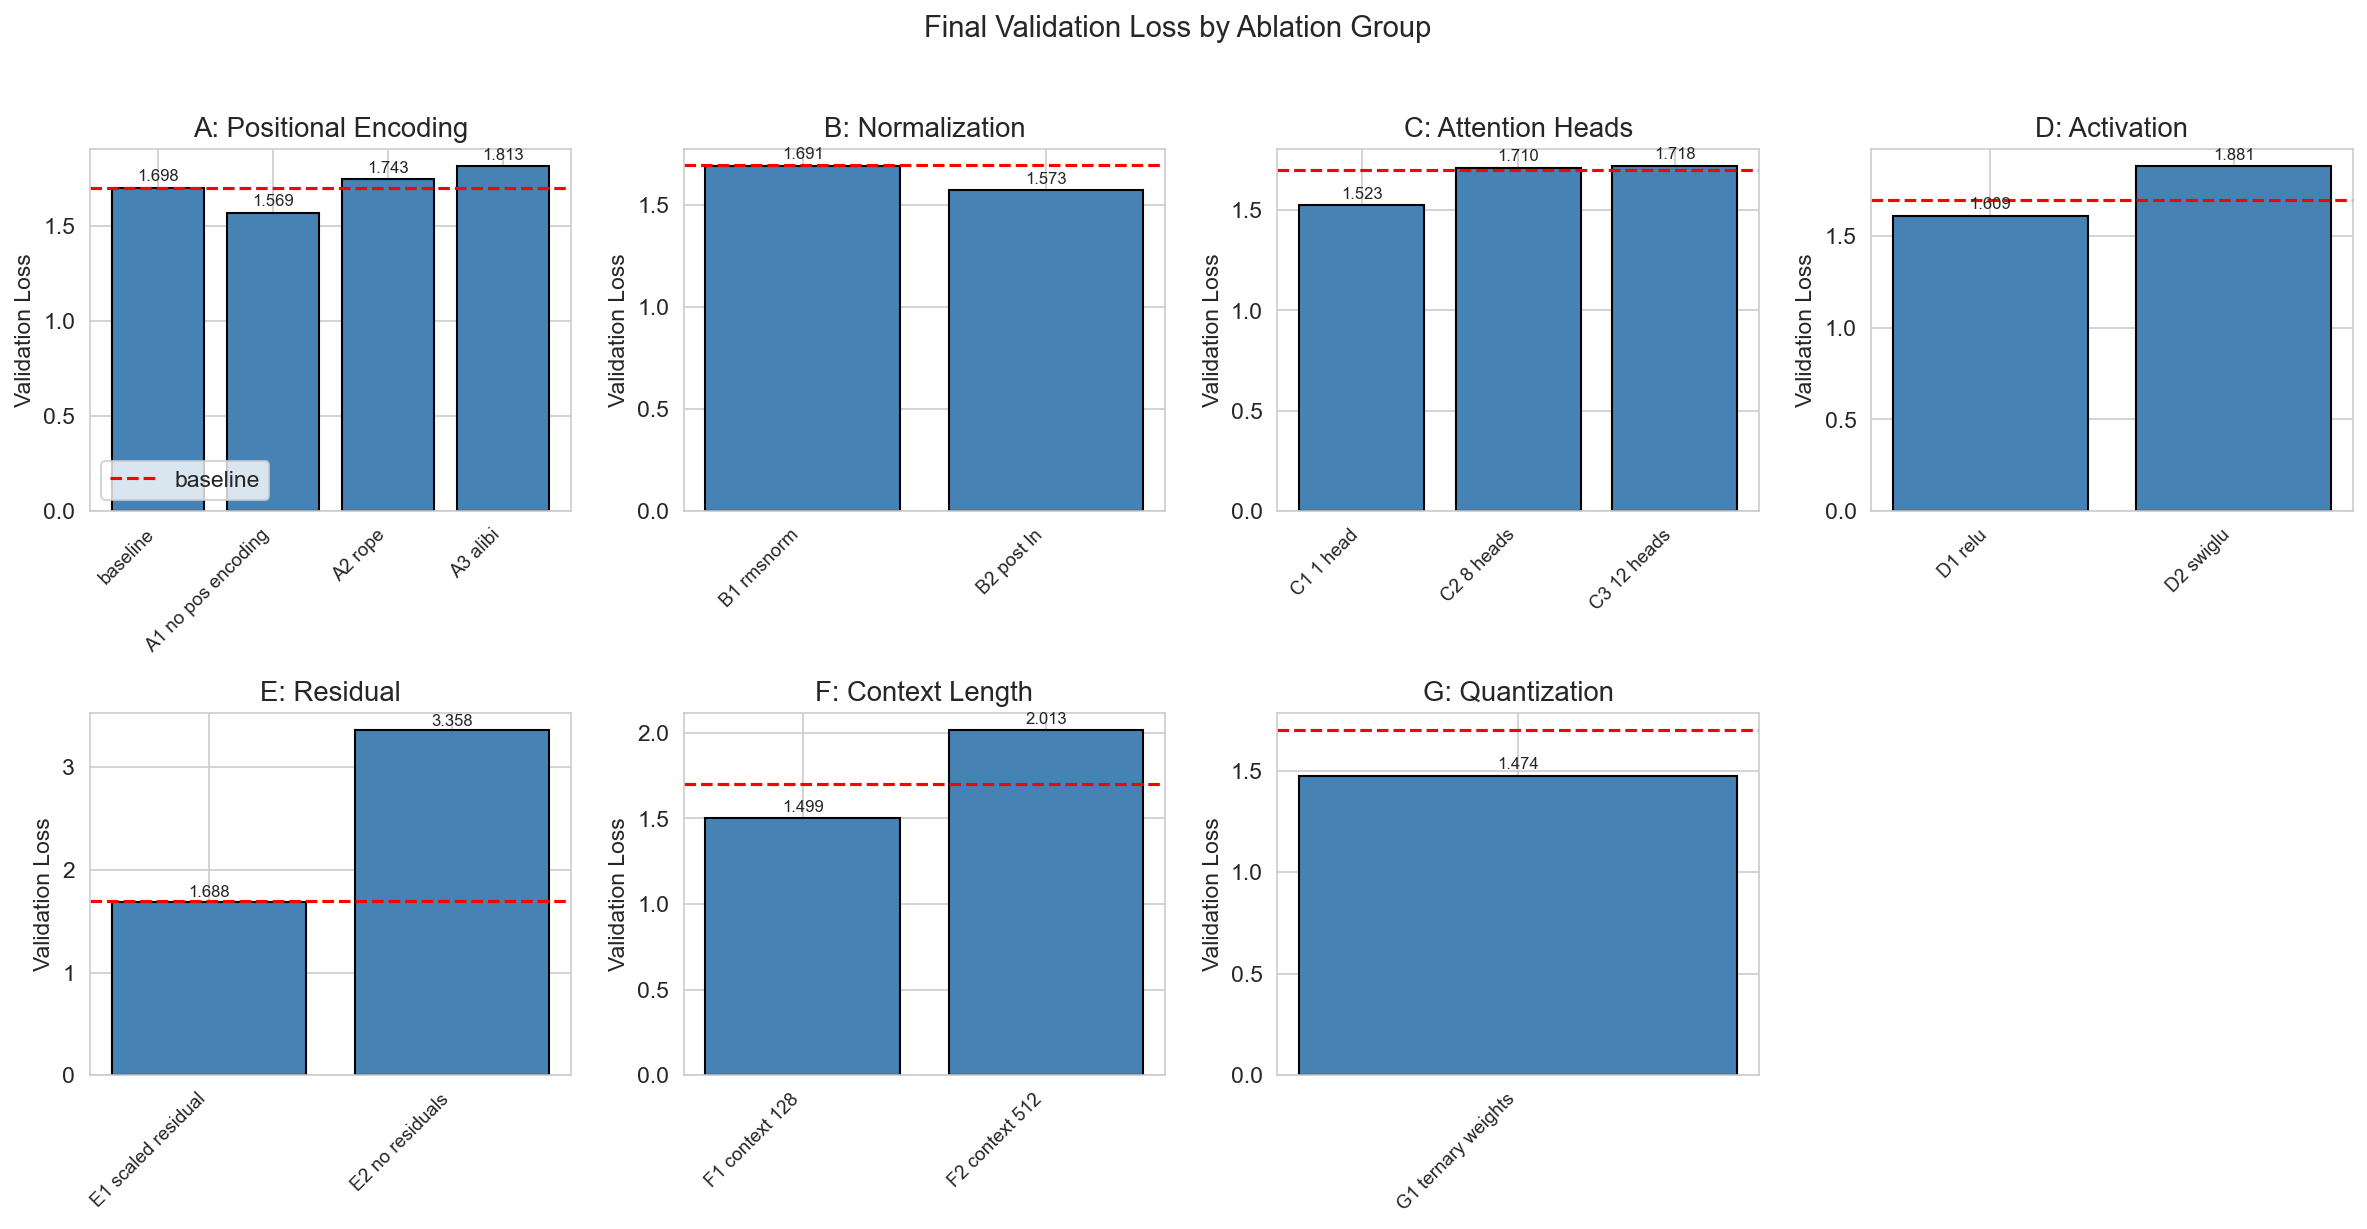

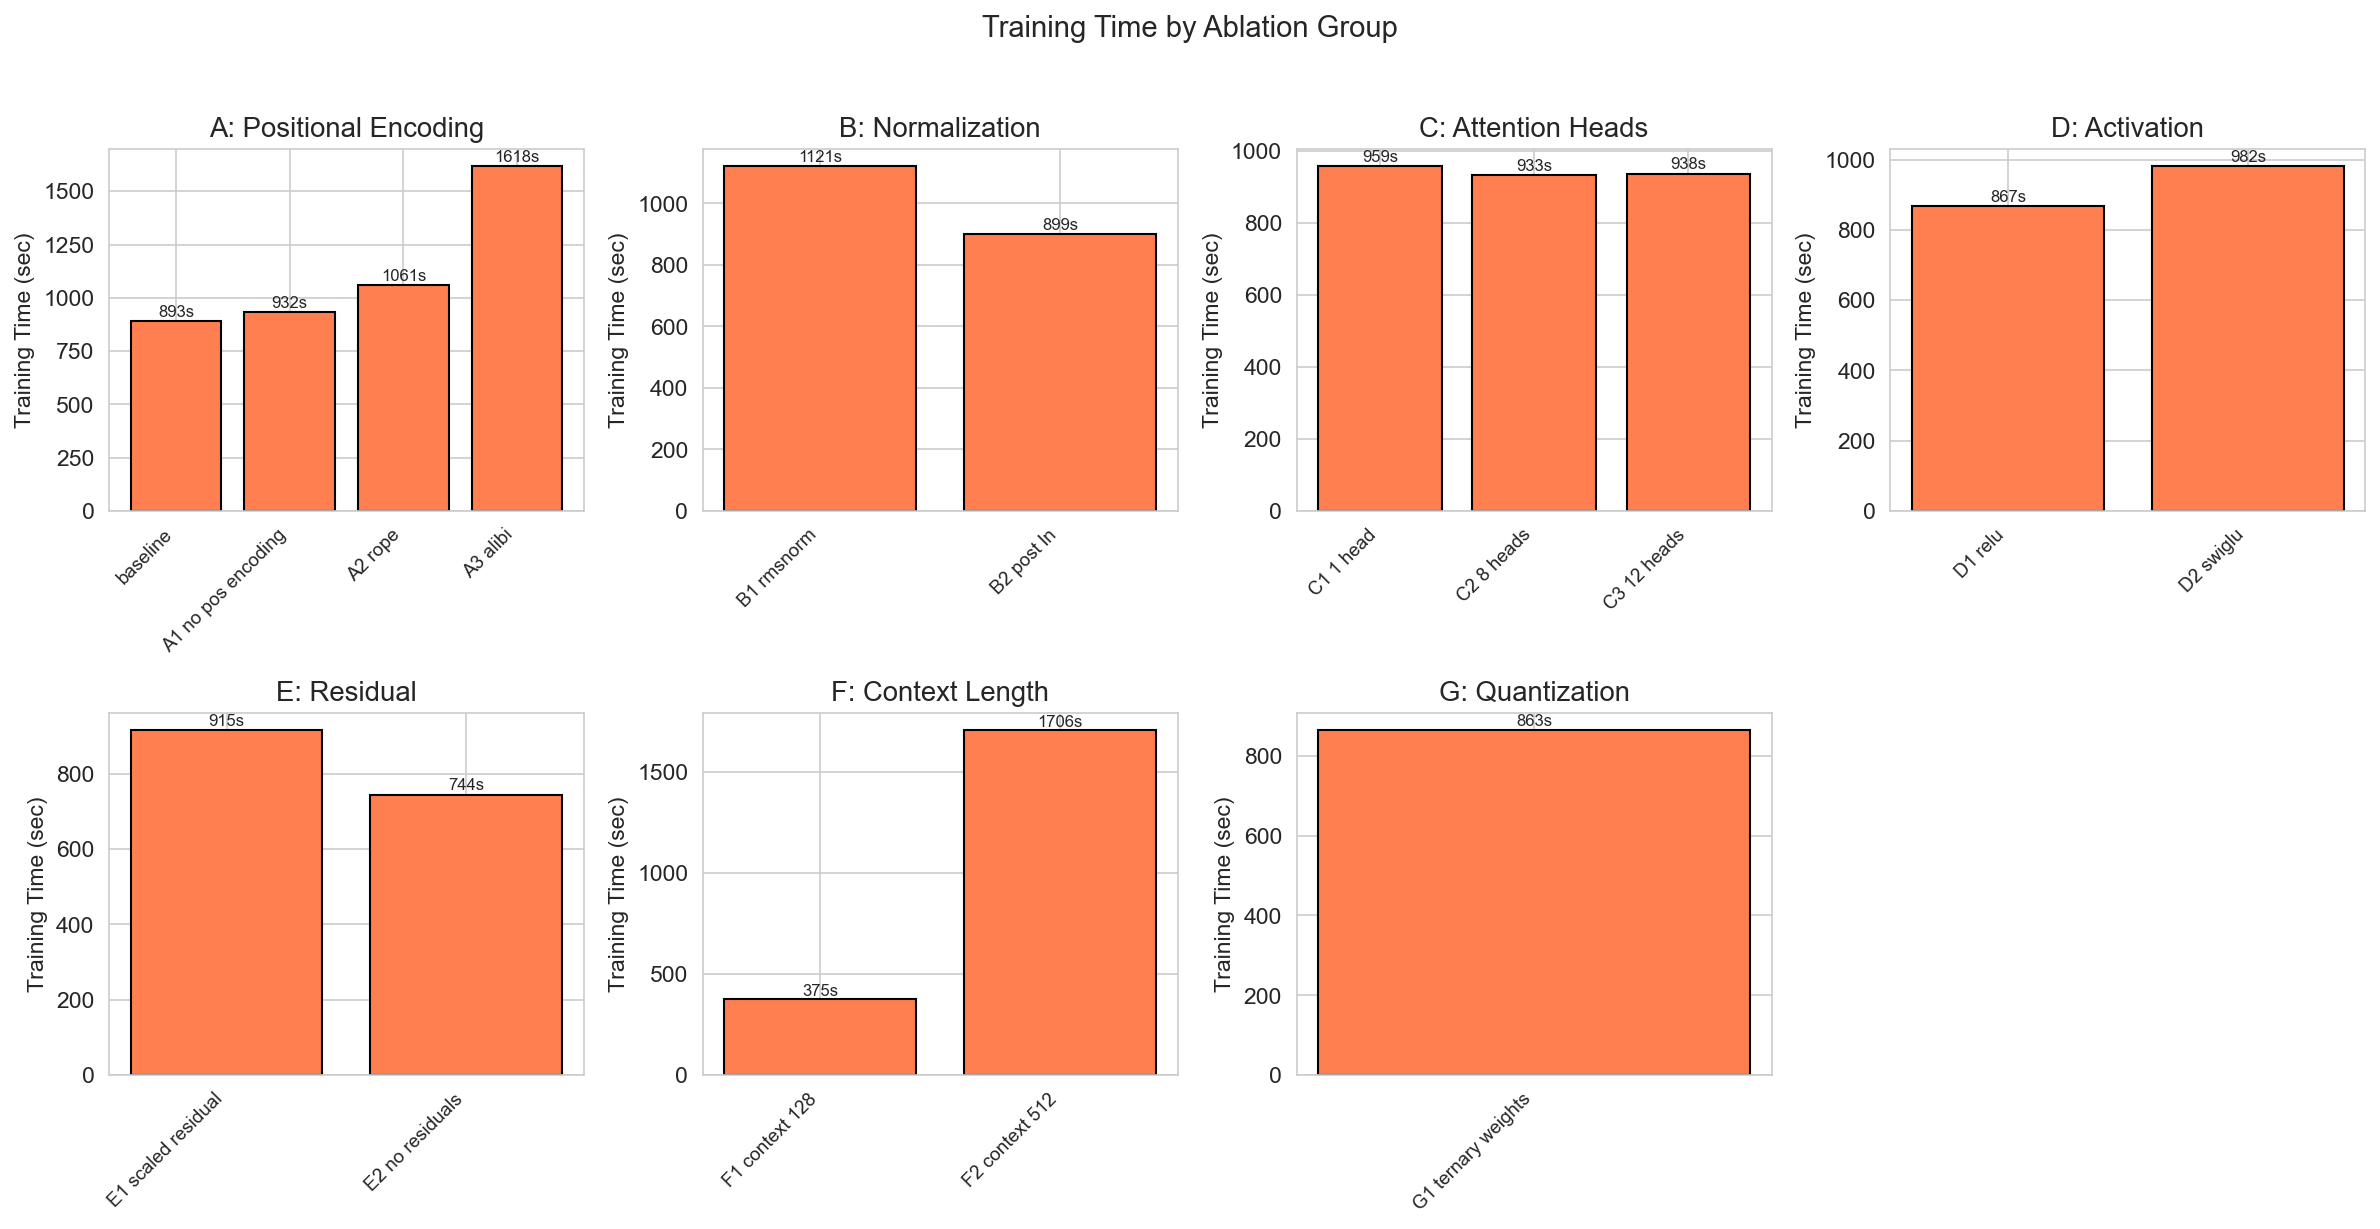


Skipping baseline (ub5c1qiz) - already downloaded
Saved history_data\A1_no_pos_encoding_ju63qi38_history.csv (rows: 523)
Saved history_data\A2_rope_g4vnk6hn_history.csv (rows: 523)
Saved history_data\A3_alibi_3lpf5xp4_history.csv (rows: 523)
Saved history_data\B1_rmsnorm_c19bsfek_history.csv (rows: 523)
Saved history_data\B2_post_ln_tkkby30t_history.csv (rows: 523)
Saved history_data\C1_1_head_vygb2qsb_history.csv (rows: 523)
Saved history_data\C2_8_heads_hrlimdob_history.csv (rows: 523)
Saved history_data\C3_12_heads_jcwg4poo_history.csv (rows: 523)
Saved history_data\D1_relu_wqd6f7cc_history.csv (rows: 523)
Saved history_data\D2_swiglu_xbmvm6gf_history.csv (rows: 523)
Saved history_data\E1_scaled_residual_jbx4ovmj_history.csv (rows: 523)
Saved history_data\E2_no_residuals_brpu5q8e_history.csv (rows: 523)
Saved history_data\F1_context_128_0l5pdqyz_history.csv (rows: 523)
Saved history_data\F2_context_512_cq9b1ady_history.csv (rows: 523)
Saved history_data\G1_ternary_weights_bvdy2tb2_

C:\Users\Rickey\AppData\Local\Temp\ipykernel_30036\1651878831.py:250: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conv_steps = combined_hist.groupby(['run_name', 'run_id']).apply(


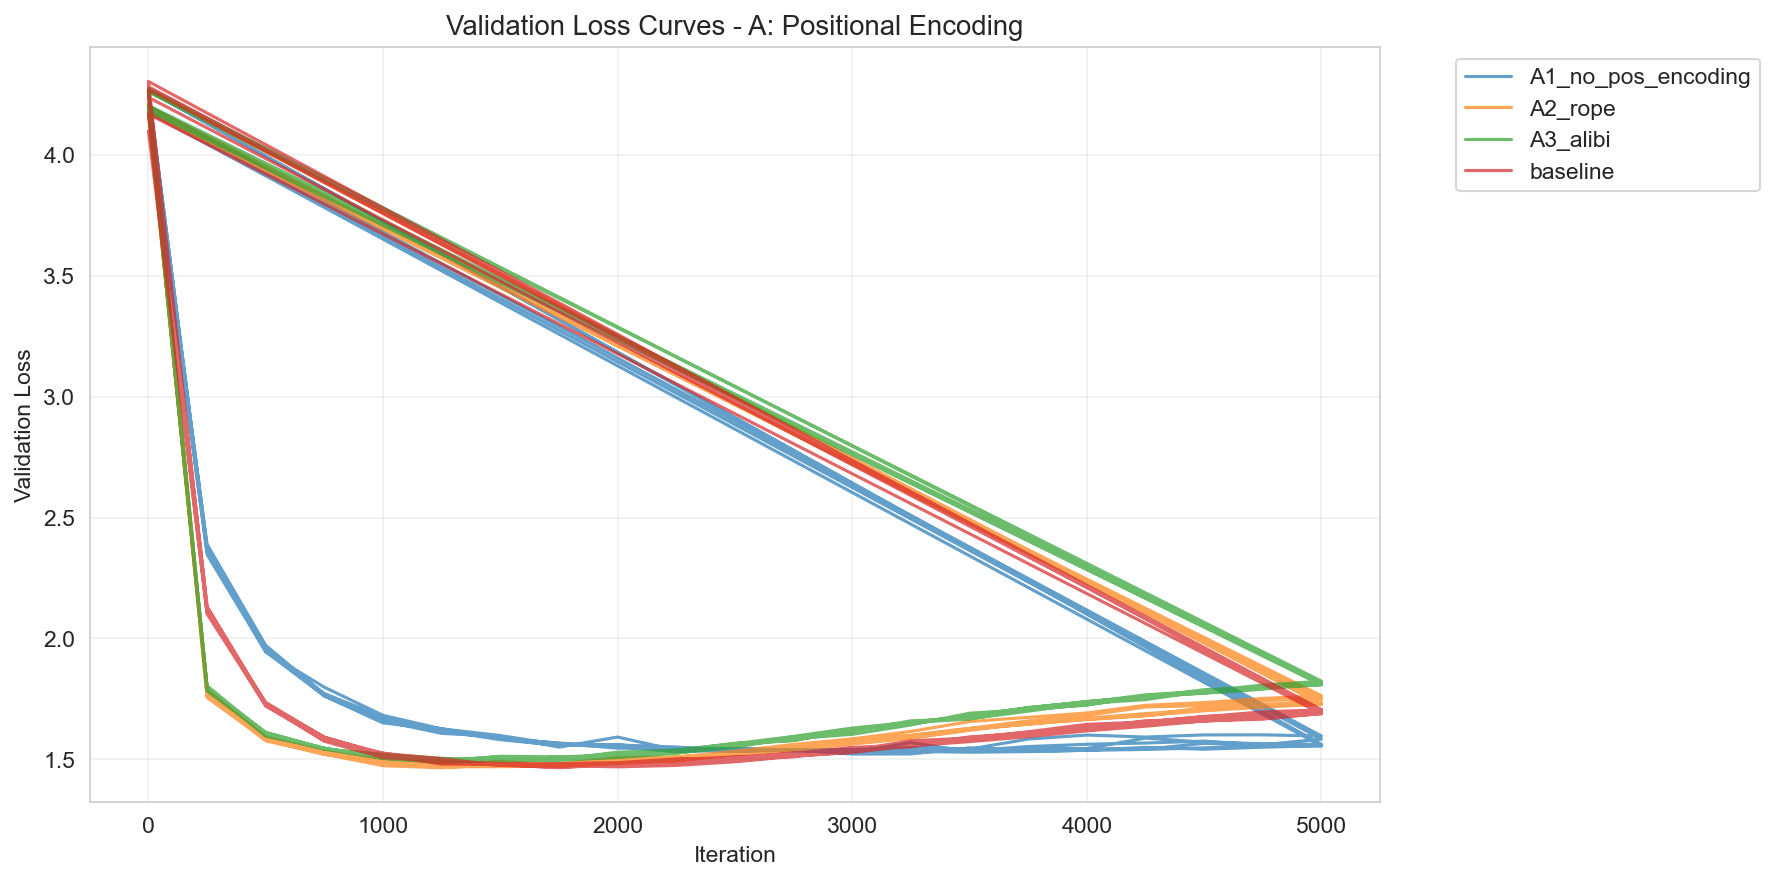

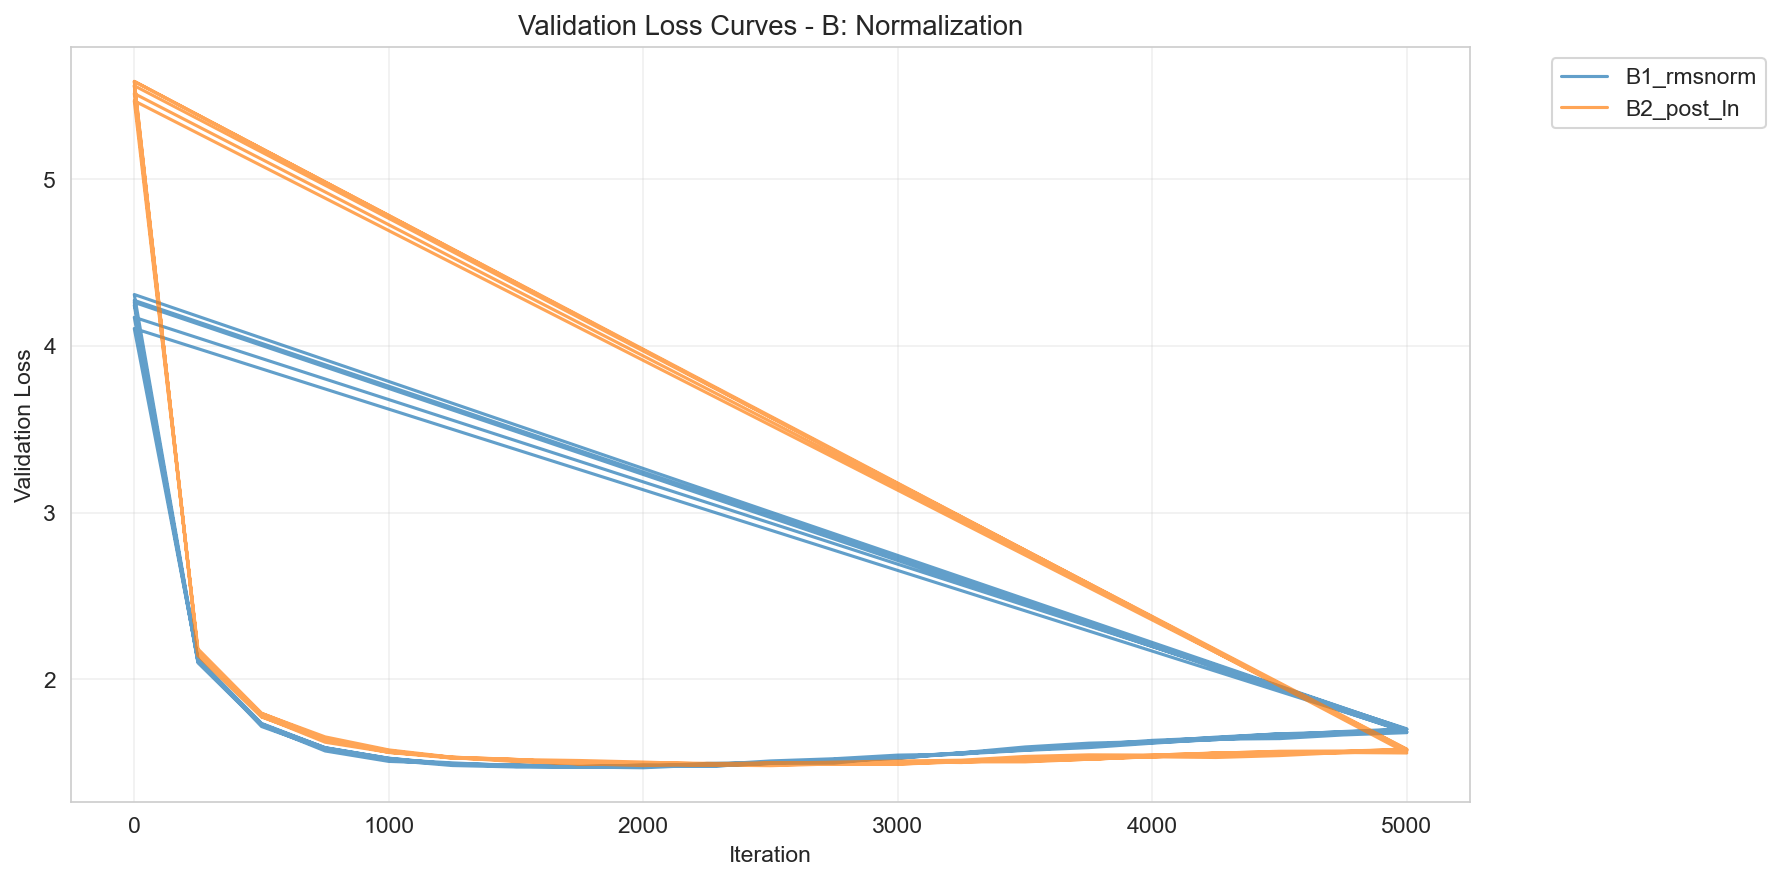

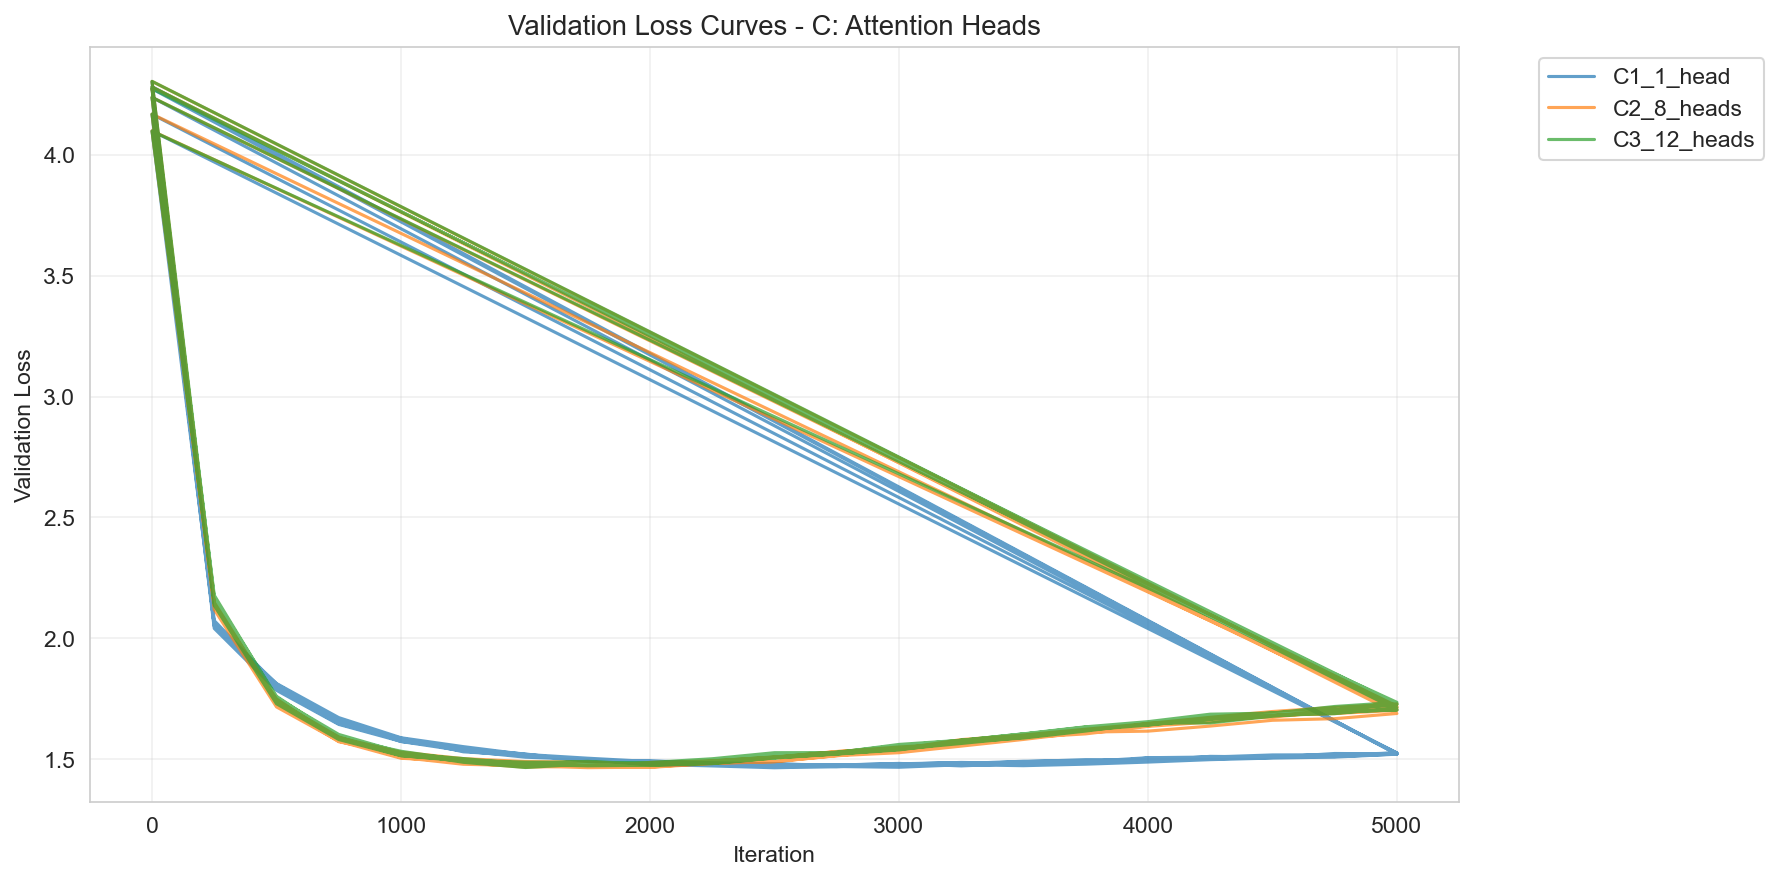

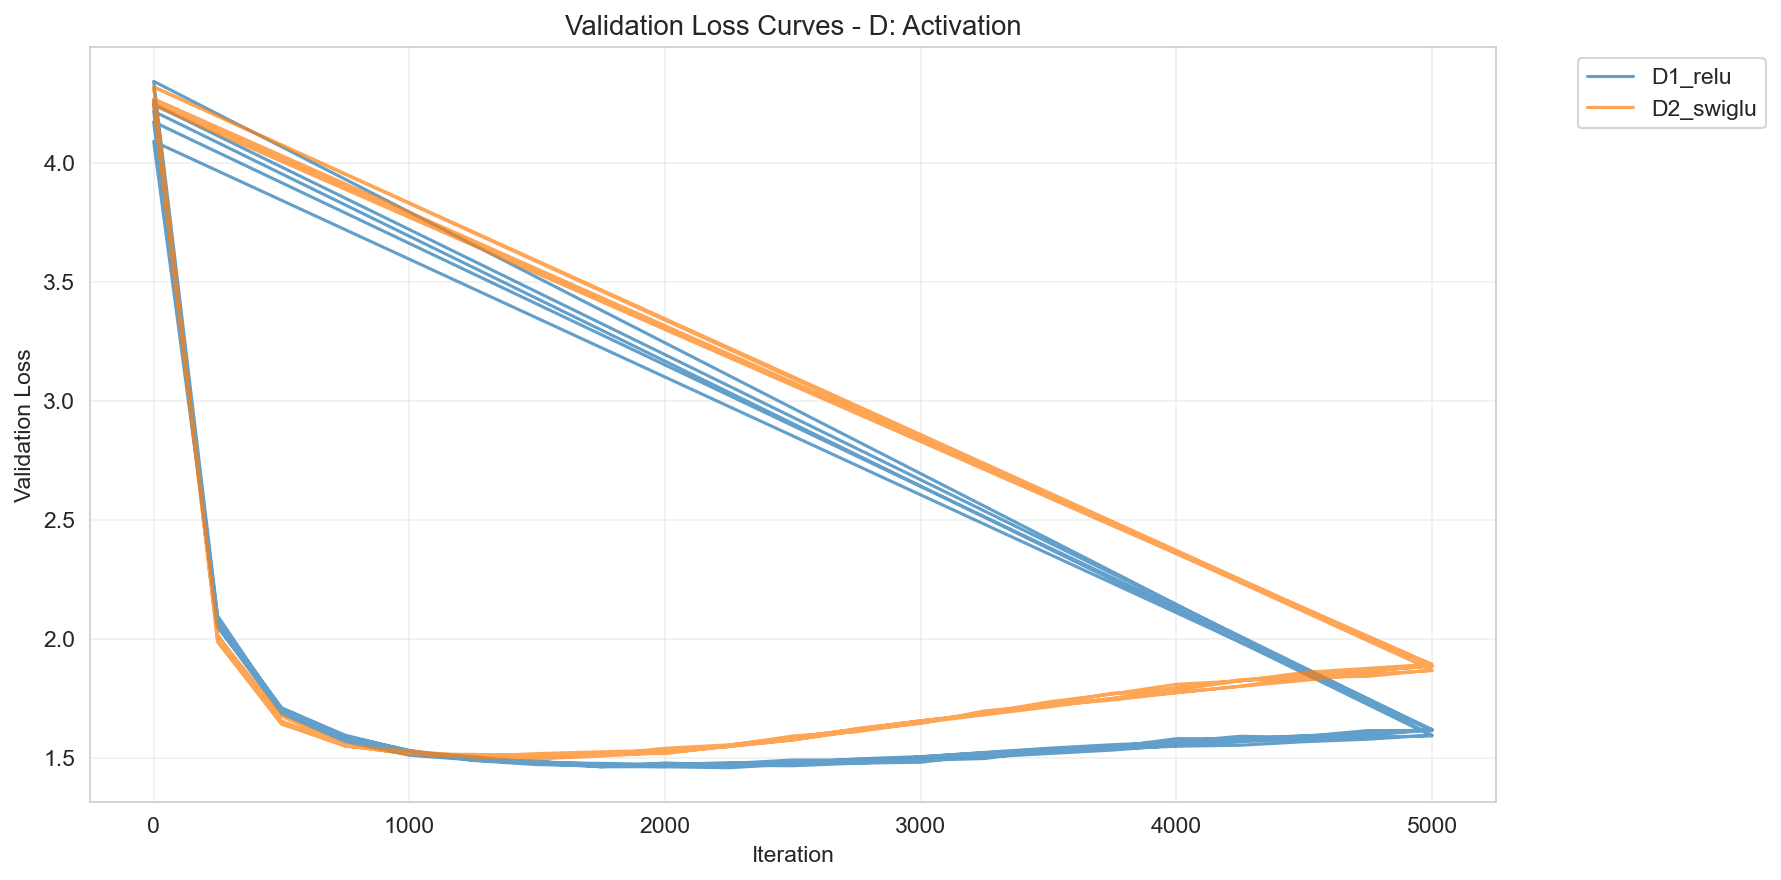

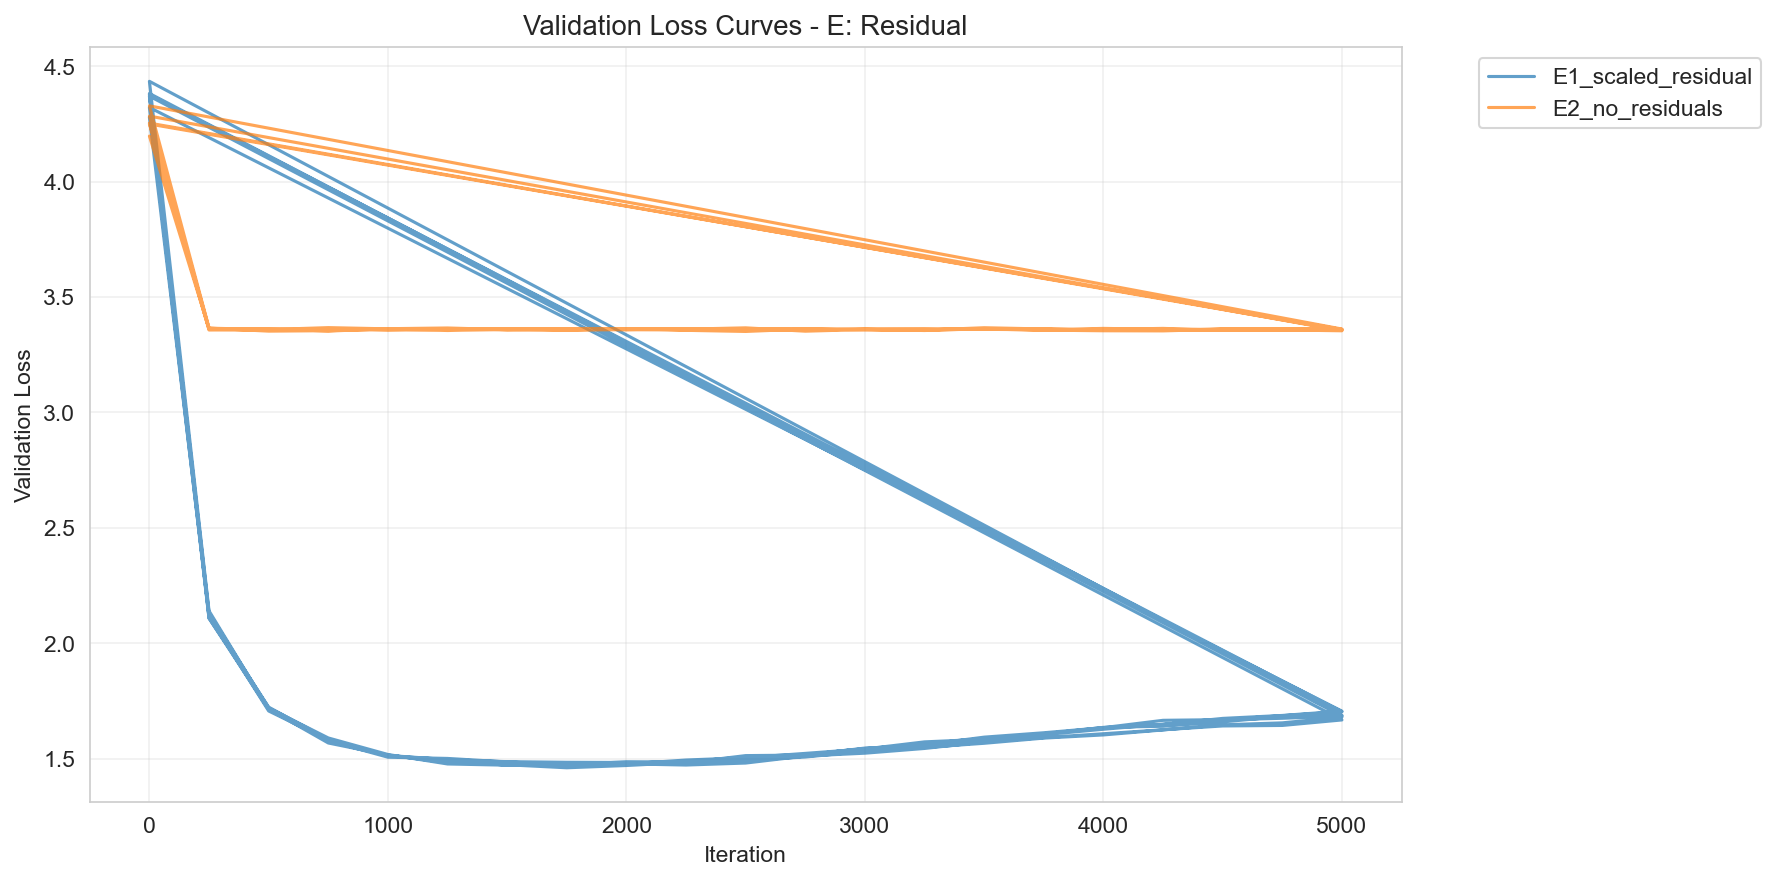

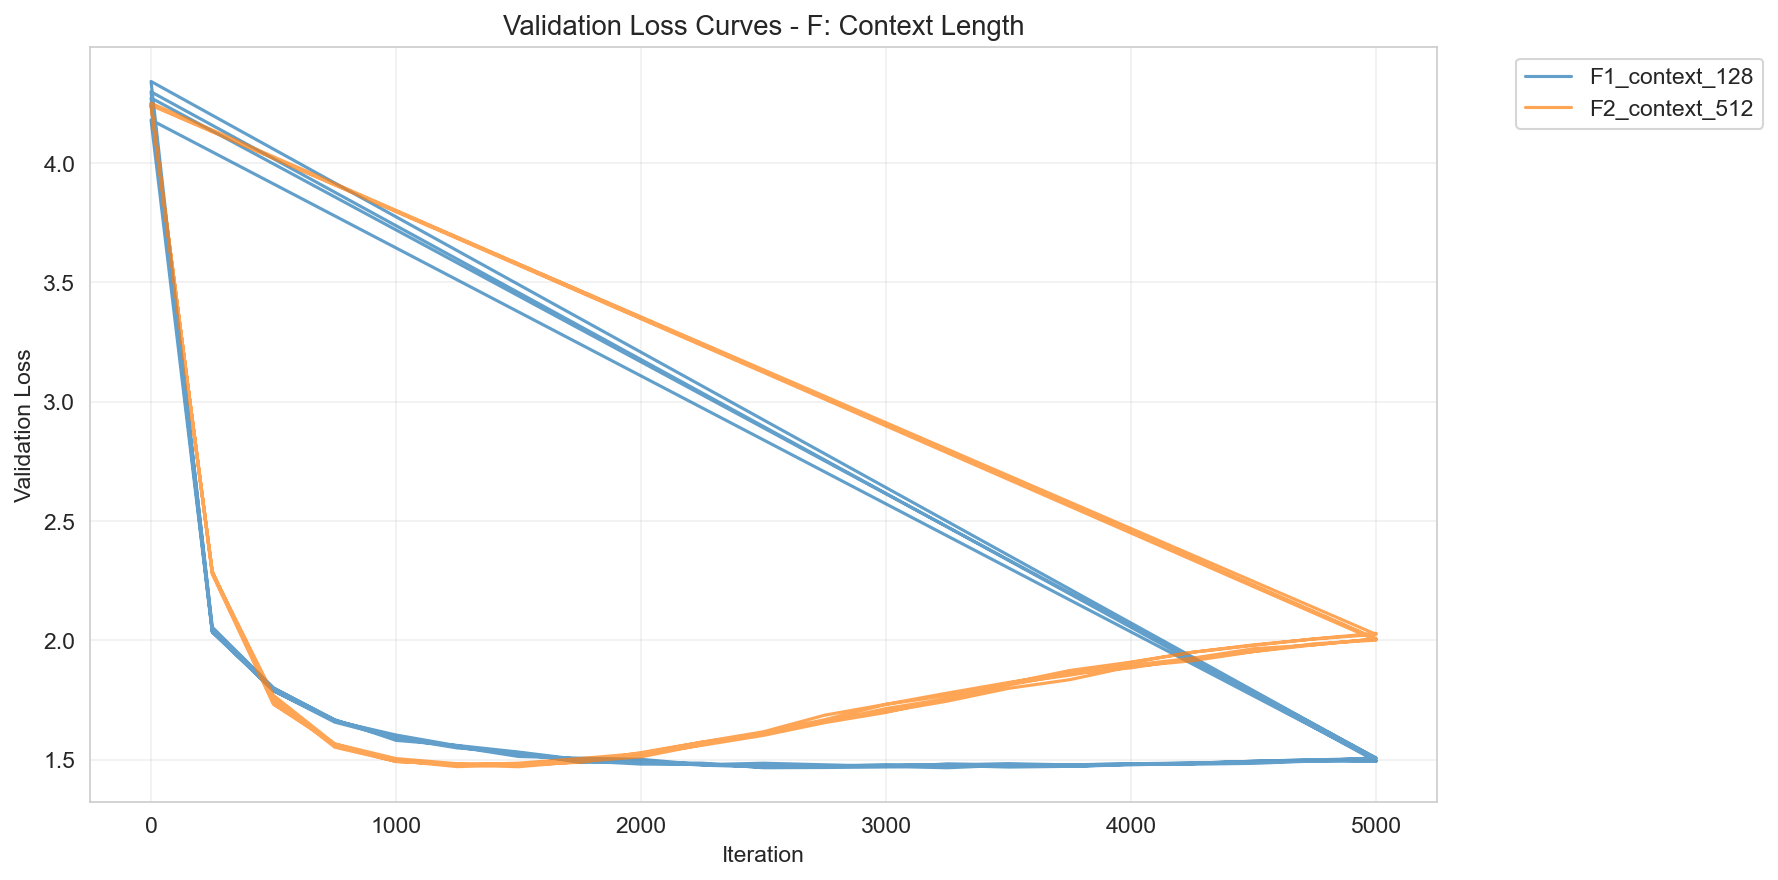

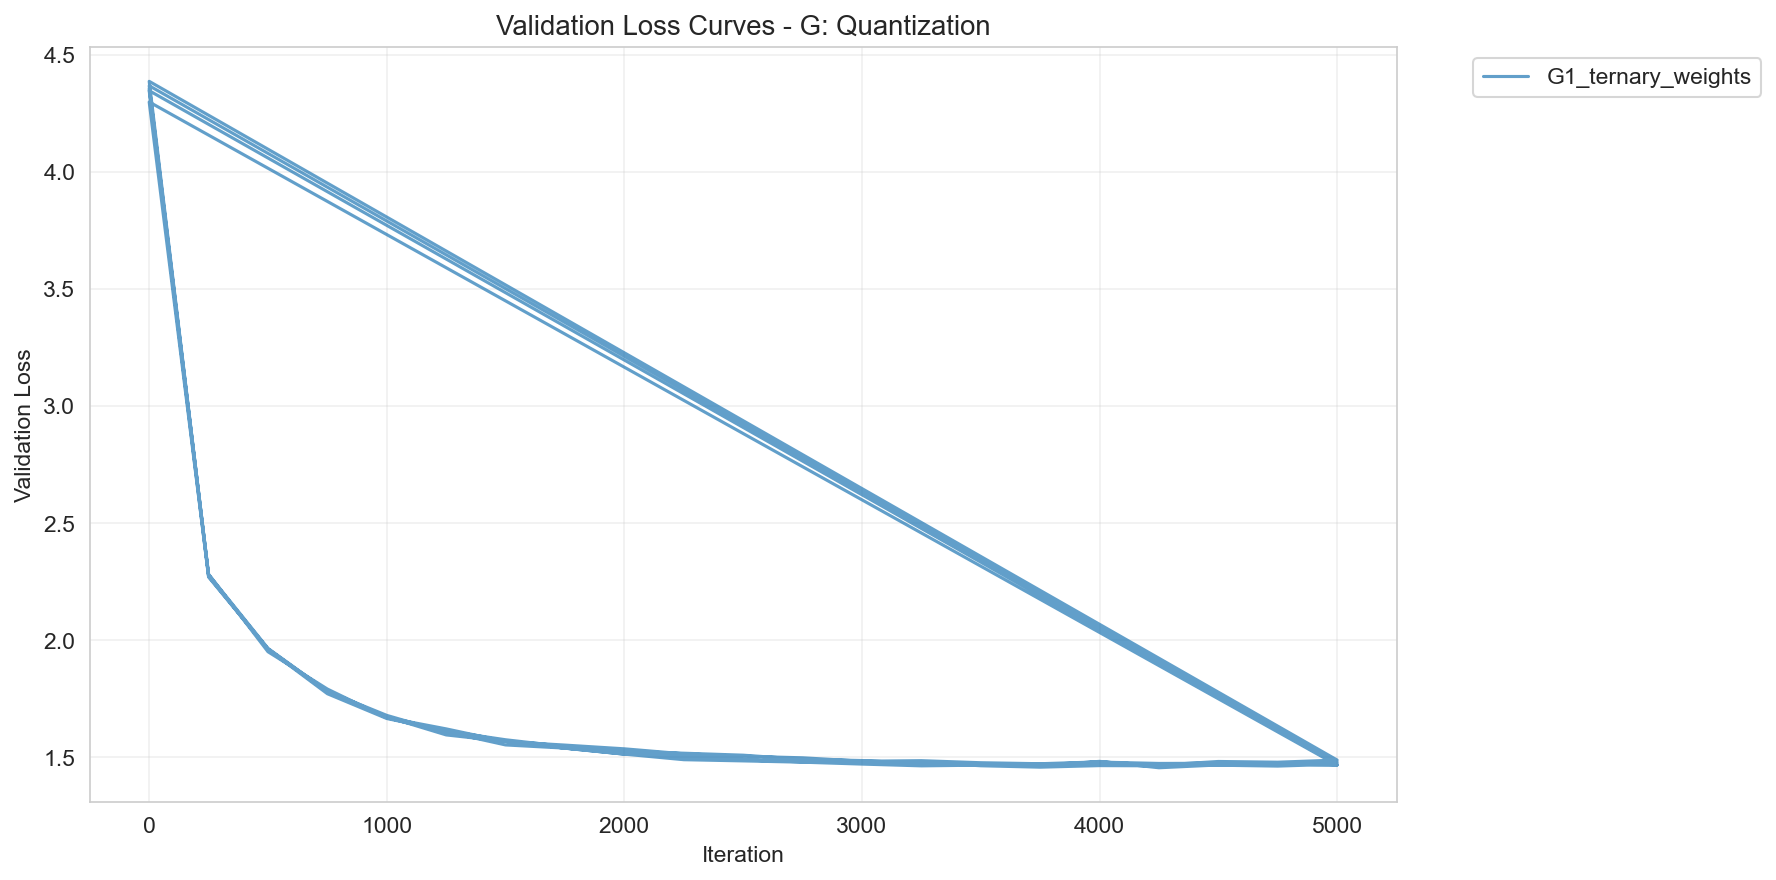

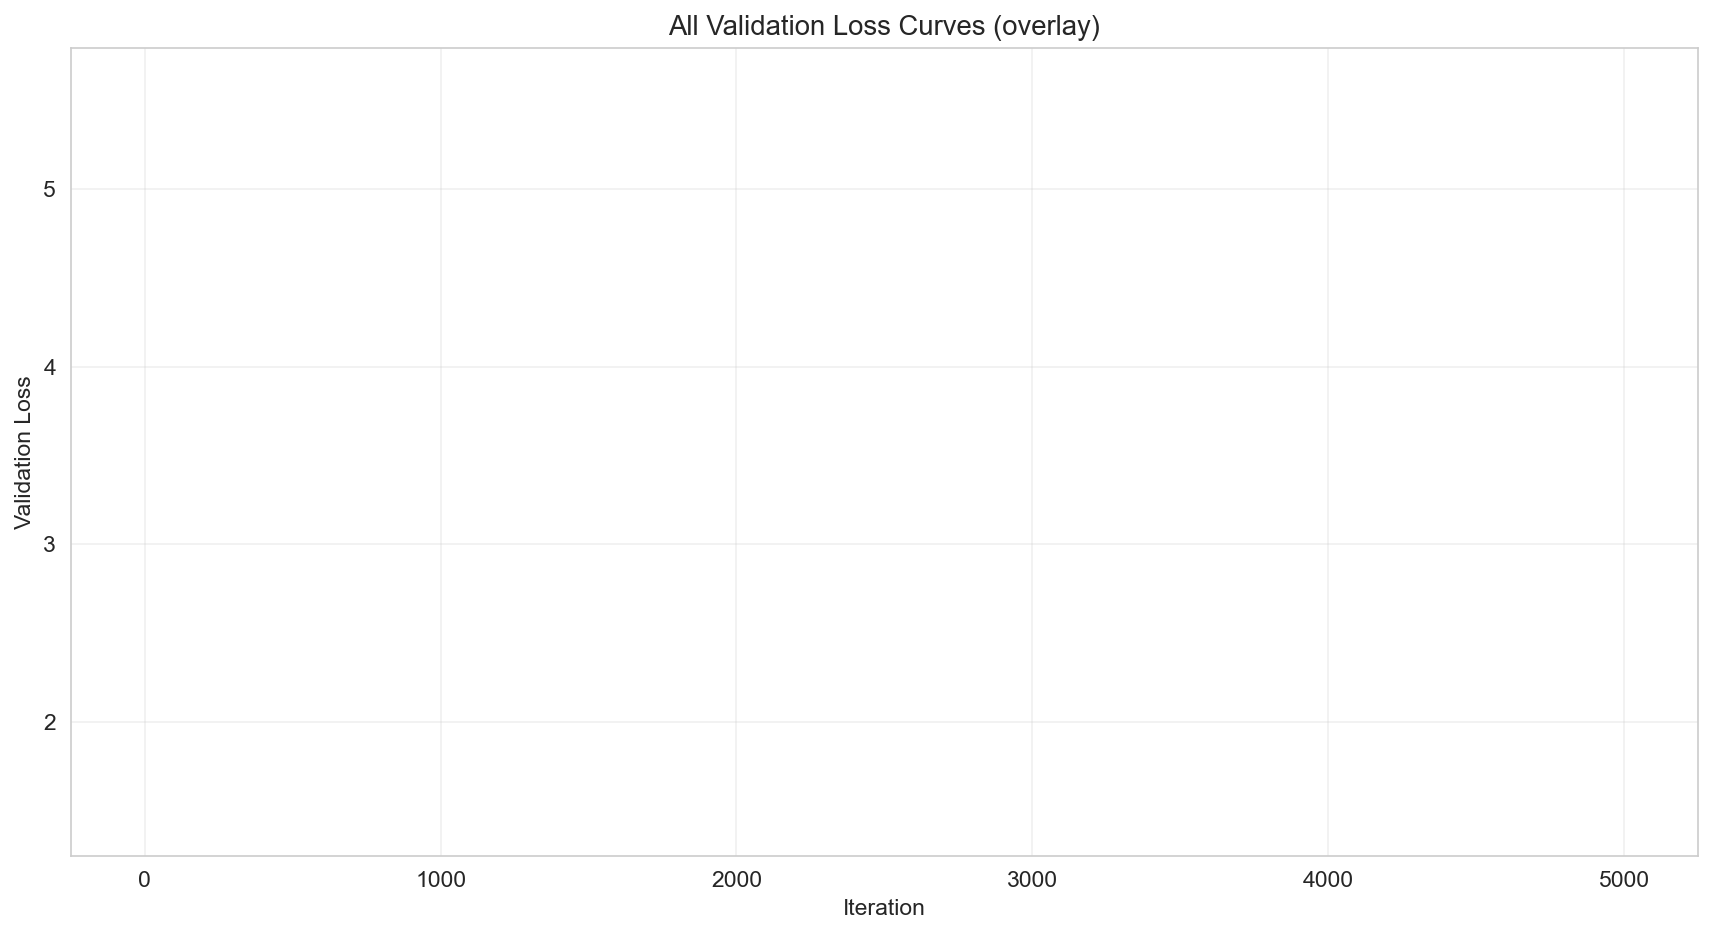


Saved output\baseline_sample.txt
Saved output\A1_no_pos_encoding_sample.txt
Saved output\E2_no_residuals_sample.txt
Saved output\G1_ternary_weights_sample.txt

Summary table saved to analysis_figures\summary_table.csv
                 Group      Configuration  Val Loss  Δ from baseline  Training Time (s)  Params (M)
A: Positional Encoding A1 no pos encoding    1.5687          -0.1293              932.2       10.65
A: Positional Encoding            A2 rope    1.7432           0.0453             1060.8       10.65
A: Positional Encoding           A3 alibi    1.8131           0.1152             1617.7       10.65
A: Positional Encoding           baseline    1.6980           0.0000              893.0       10.75
      B: Normalization         B1 rmsnorm    1.6913          -0.0066             1121.2       10.75
      B: Normalization         B2 post ln    1.5725          -0.1254              899.3       10.75
    C: Attention Heads          C1 1 head    1.5227          -0.1752             

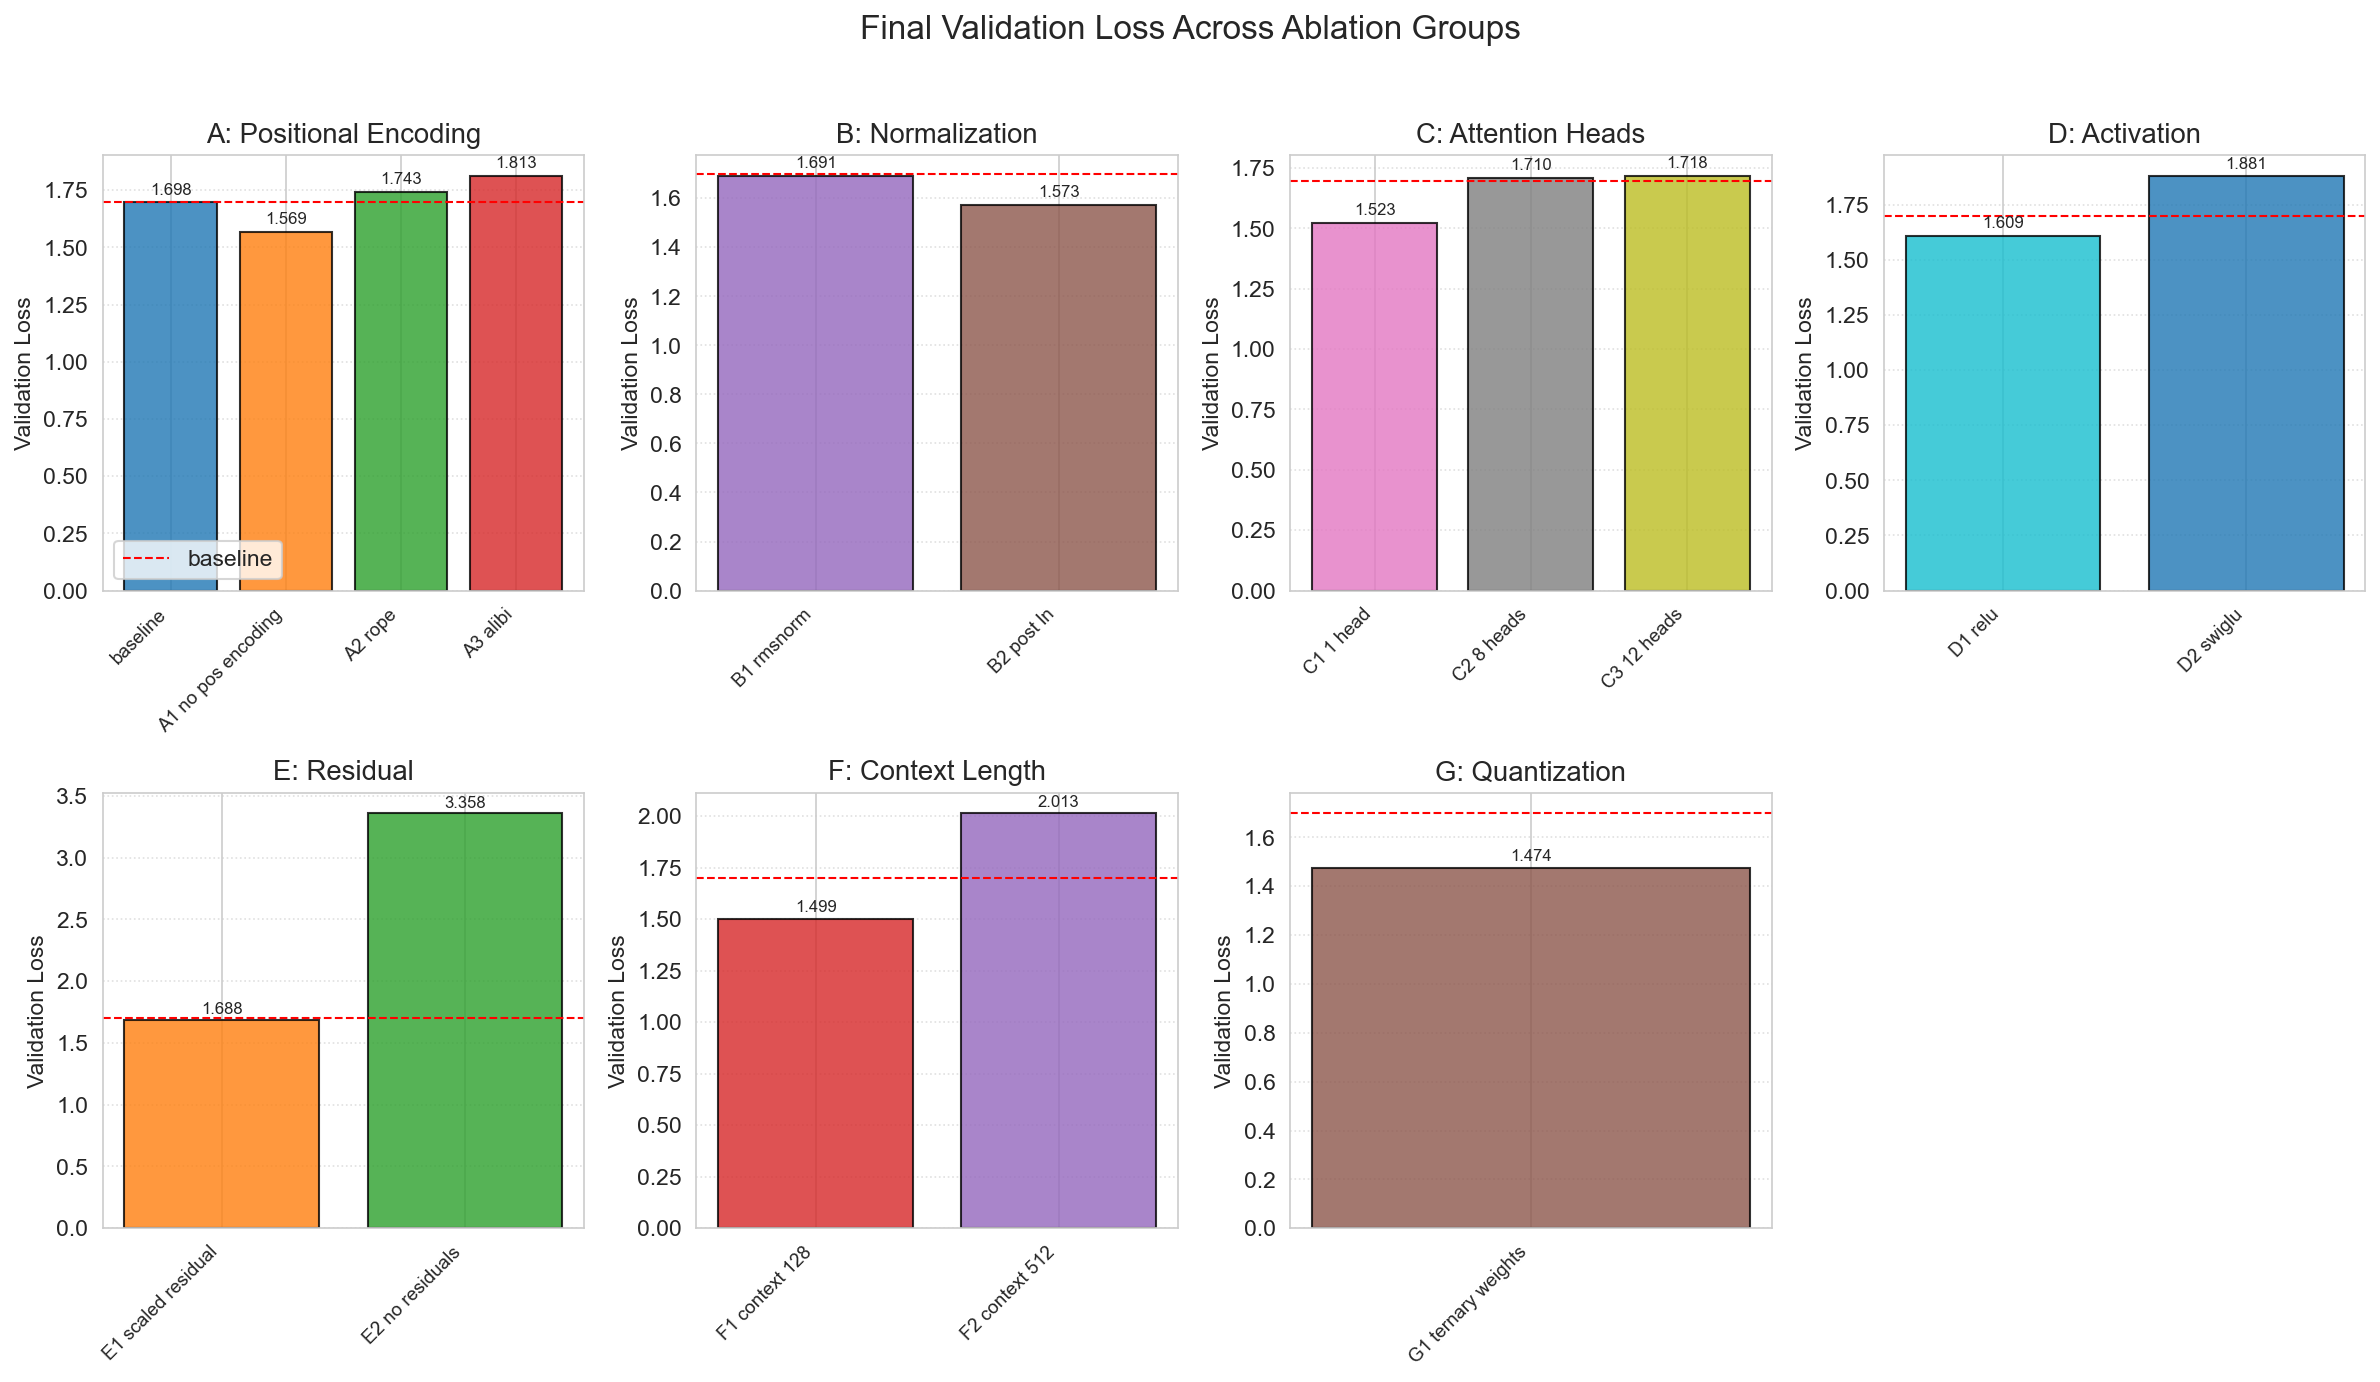

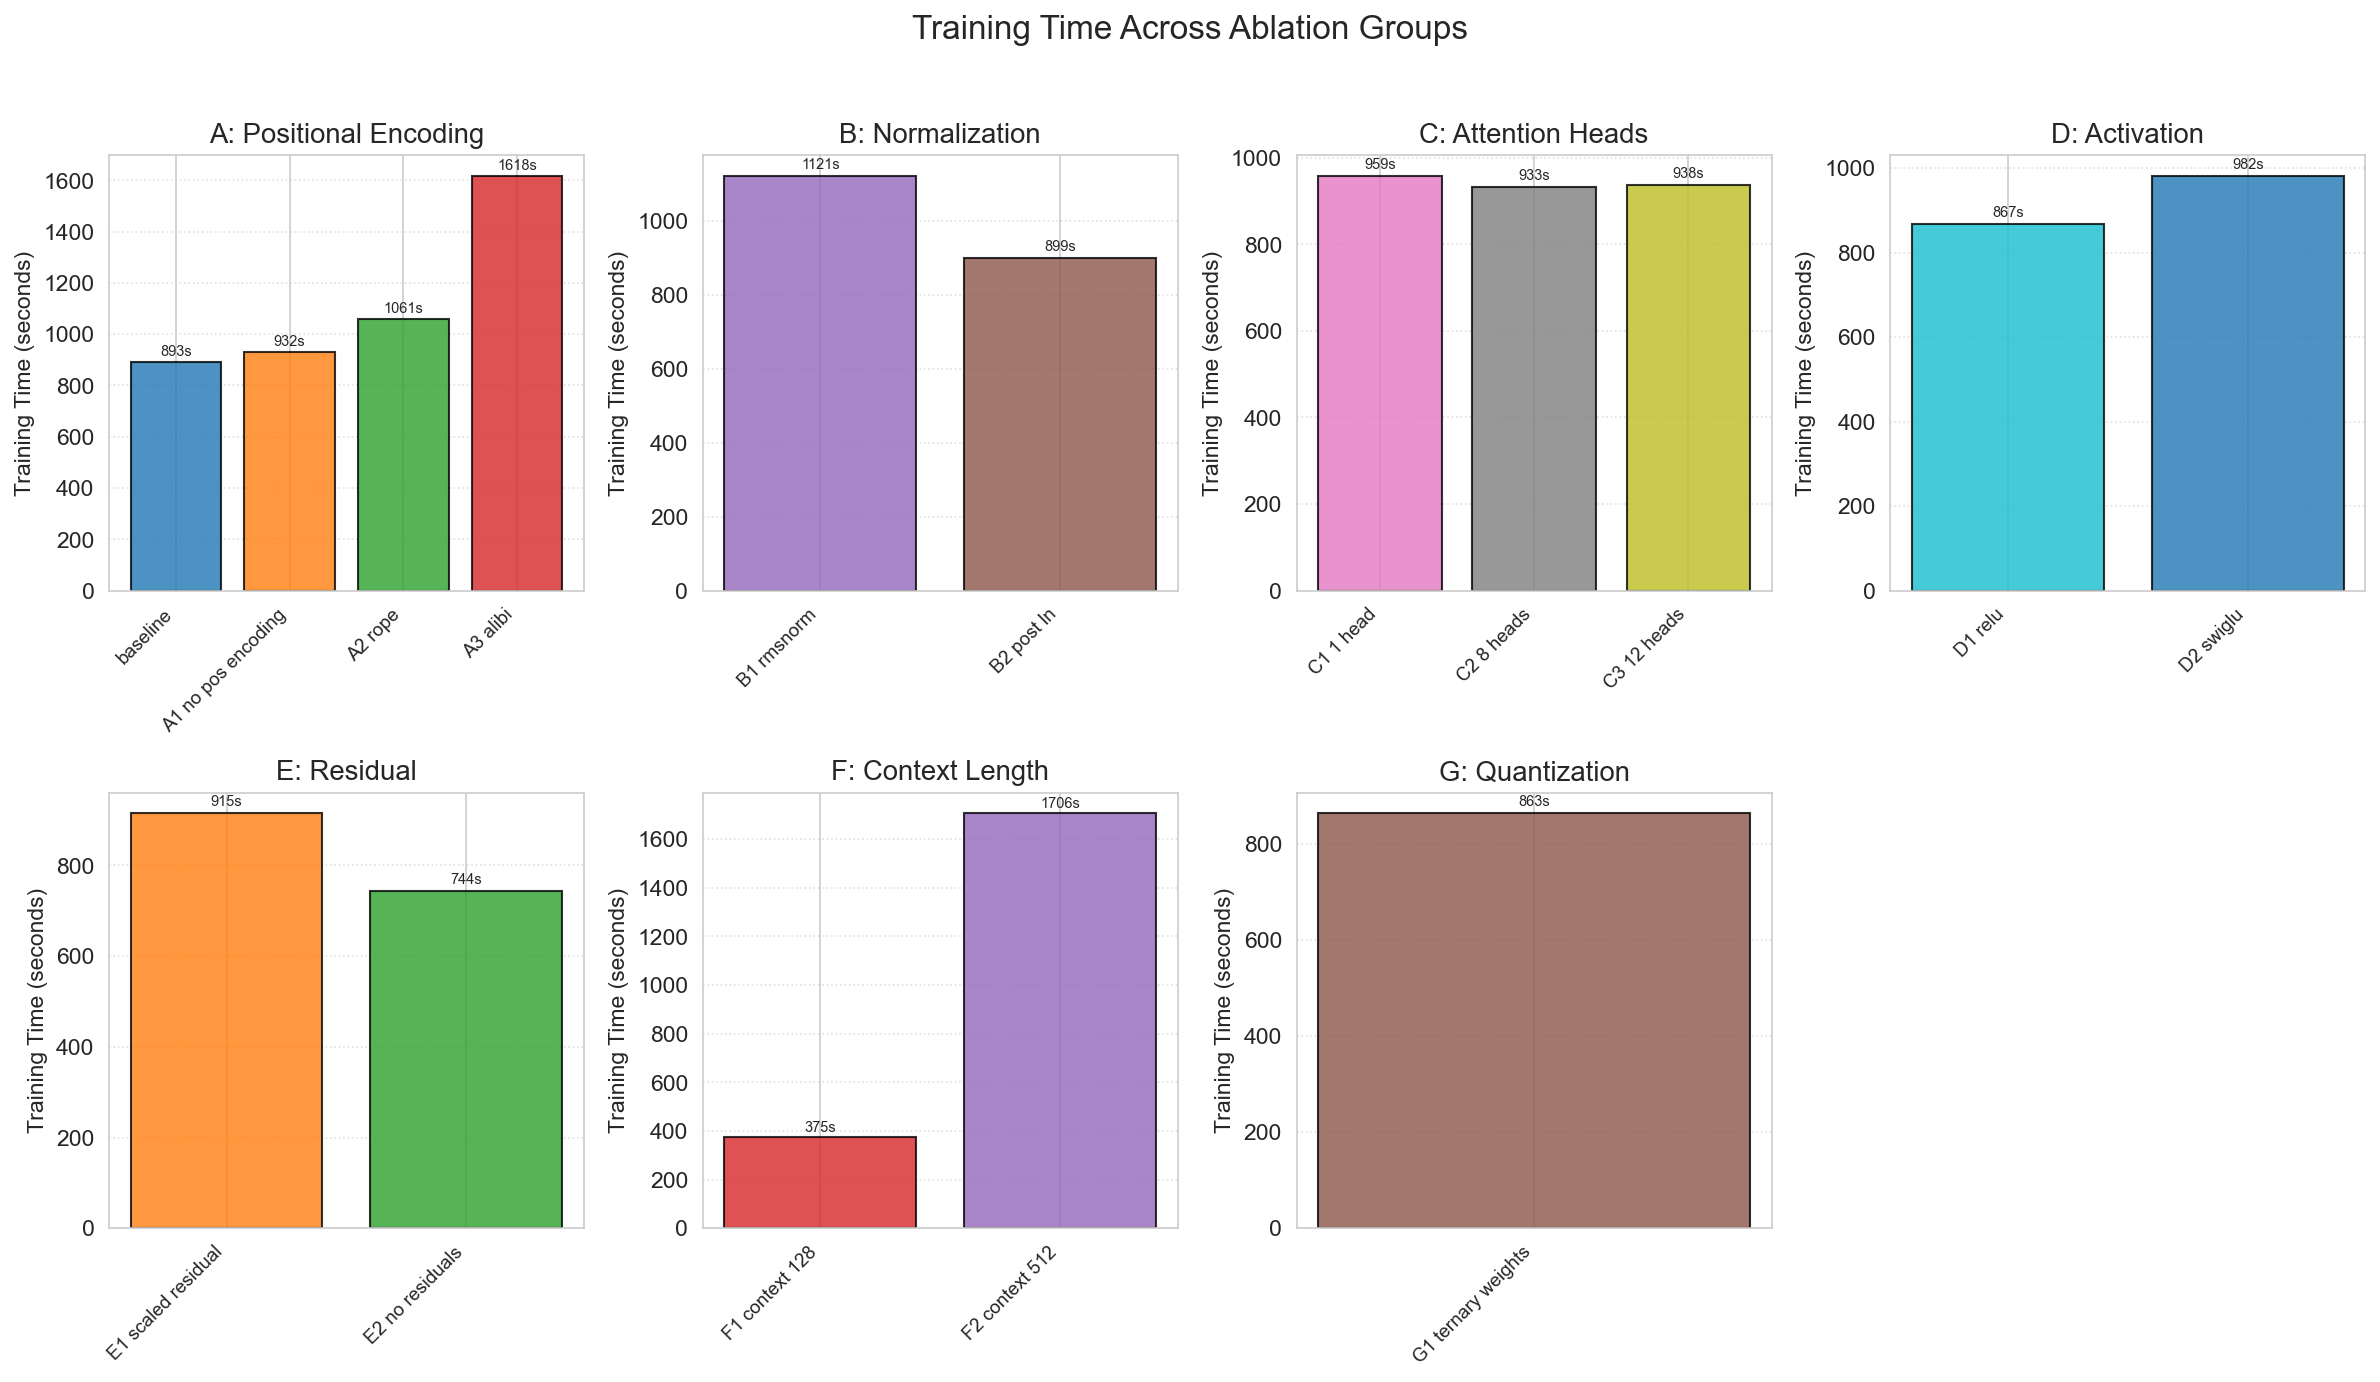

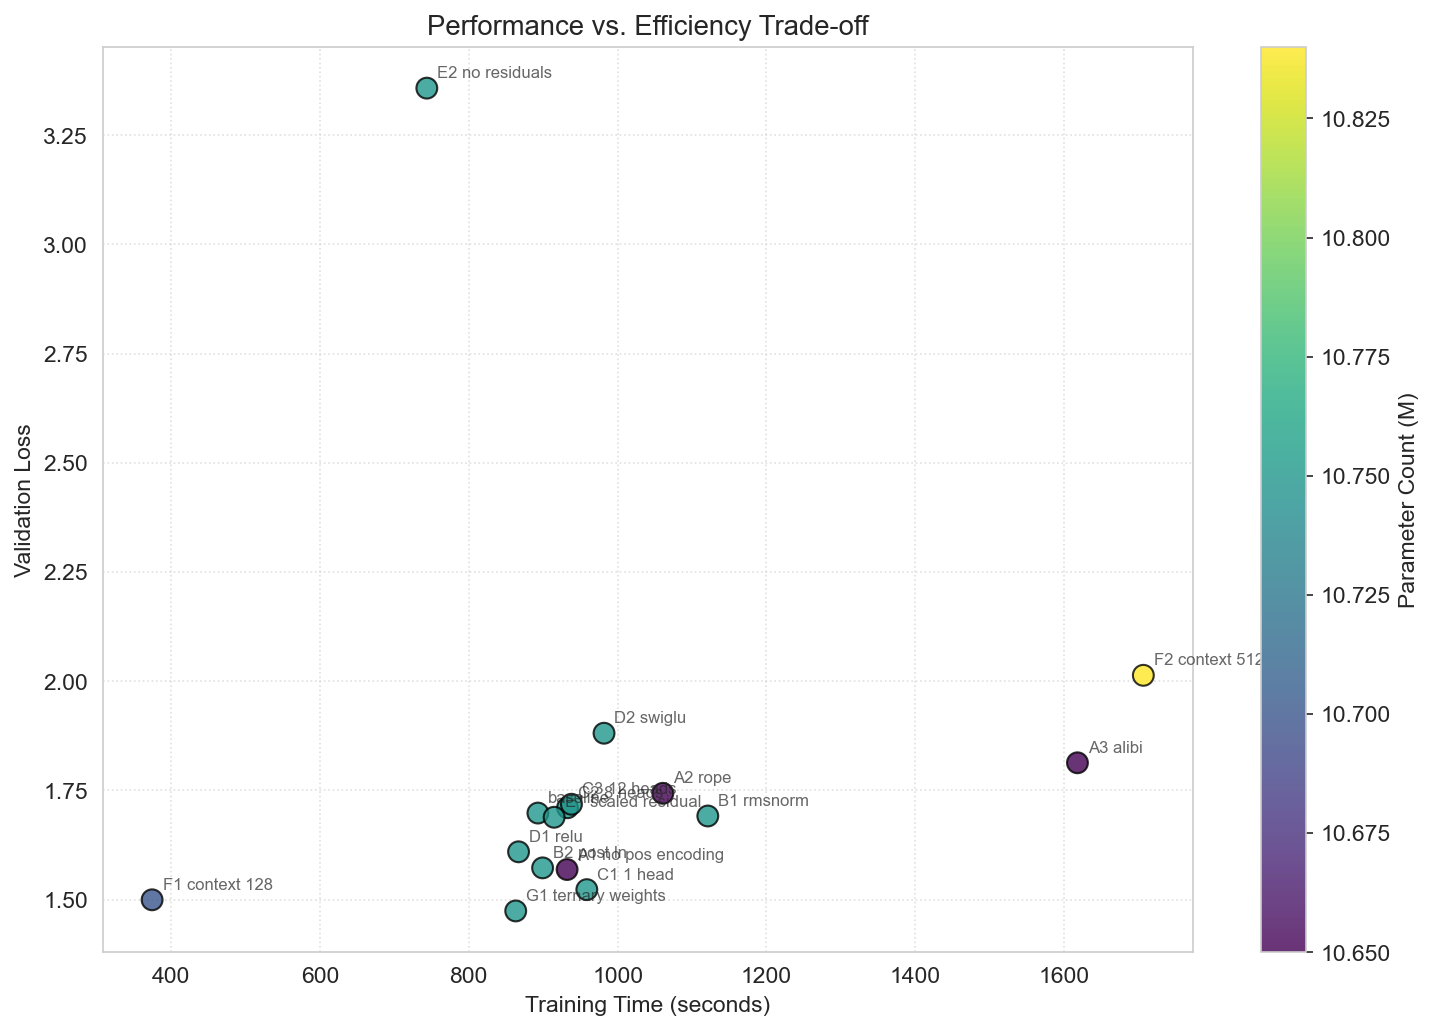


All analysis completed.


In [3]:
#!/usr/bin/env python
# coding: utf-8

# ==================================================
# Complete Experiment Results Analysis Notebook
# ==================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from bs4 import BeautifulSoup
import time

# ----- Configuration -----
ENTITY = "madhavkrishnan747-australian-national-university"
PROJECT = "nanogpt-ablations"
SUMMARY_CSV = "wandb_summary.csv"
OUTPUT_DIR = "analysis_figures"
HISTORY_DIR = "history_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150

# ==================================================
# 1. Fetch or load summary data from wandb (keep _runtime)
# ==================================================
def fetch_or_load_summary(force_refresh=False):
    if not force_refresh and os.path.exists(SUMMARY_CSV):
        print(f"Using existing file {SUMMARY_CSV}")
        return pd.read_csv(SUMMARY_CSV)
    
    print("Fetching data from wandb...")
    api = wandb.Api()
    runs = api.runs(f"{ENTITY}/{PROJECT}")
    records = []
    for run in runs:
        summary = dict(run.summary)
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        record = {
            'run_name': run.name,
            'run_id': run.id,
            'state': run.state,
            'created_at': run.created_at,
            'url': run.url,
            **config,
            **summary
        }
        records.append(record)
    df = pd.DataFrame(records)
    if '_runtime' in df.columns:
        df['training_time_sec'] = df['_runtime']
    else:
        df['training_time_sec'] = np.nan
    df.to_csv(SUMMARY_CSV, index=False)
    print(f"Saved to {SUMMARY_CSV}")
    return df

df_all = fetch_or_load_summary(force_refresh=False)

# Keep only finished runs with iter==5000 and valid training time
df_valid = df_all[(df_all['state'] == 'finished') & (df_all['iter'] == 5000) & (df_all['training_time_sec'].notna())].copy()
print(f"Number of valid runs: {len(df_valid)}")

# Average multiple seeds per run_name
df_mean = df_valid.groupby('run_name').agg({
    'val/loss': 'mean',
    'train/loss': 'mean',
    'training_time_sec': 'mean',
    'n_params': 'first'
}).reset_index()

print("\n===== Average performance (sorted by val/loss) =====")
df_sorted = df_mean.sort_values('val/loss')
print(df_sorted[['run_name', 'val/loss', 'training_time_sec']].to_string(index=False))

# ==================================================
# 2. Define ablation groups and basic plots
# ==================================================
group_mapping = {
    'baseline': 'A: Positional Encoding',
    'A1_no_pos_encoding': 'A: Positional Encoding',
    'A2_rope': 'A: Positional Encoding',
    'A3_alibi': 'A: Positional Encoding',
    'B1_rmsnorm': 'B: Normalization',
    'B2_post_ln': 'B: Normalization',
    'C1_1_head': 'C: Attention Heads',
    'C2_8_heads': 'C: Attention Heads',
    'C3_12_heads': 'C: Attention Heads',
    'D1_relu': 'D: Activation',
    'D2_swiglu': 'D: Activation',
    'E1_scaled_residual': 'E: Residual',
    'E2_no_residuals': 'E: Residual',
    'F1_context_128': 'F: Context Length',
    'F2_context_512': 'F: Context Length',
    'G1_ternary_weights': 'G: Quantization'
}
df_mean['group'] = df_mean['run_name'].map(group_mapping)
df_mean['short_name'] = df_mean['run_name'].str.replace('_', ' ')

order_dict = {
    'A: Positional Encoding': ['baseline', 'A1_no_pos_encoding', 'A2_rope', 'A3_alibi'],
    'B: Normalization': ['baseline', 'B1_rmsnorm', 'B2_post_ln'],
    'C: Attention Heads': ['baseline', 'C1_1_head', 'C2_8_heads', 'C3_12_heads'],
    'D: Activation': ['baseline', 'D1_relu', 'D2_swiglu'],
    'E: Residual': ['baseline', 'E1_scaled_residual', 'E2_no_residuals'],
    'F: Context Length': ['baseline', 'F1_context_128', 'F2_context_512'],
    'G: Quantization': ['baseline', 'G1_ternary_weights']
}
groups = df_mean['group'].dropna().unique()
baseline_val = df_mean[df_mean['run_name']=='baseline']['val/loss'].values[0]

# Plot validation loss by group
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for idx, group_name in enumerate(sorted(groups)):
    ax = axes[idx]
    subset = df_mean[df_mean['group'] == group_name].copy()
    ordered_names = order_dict[group_name]
    subset['order'] = subset['run_name'].map({name: i for i, name in enumerate(ordered_names)})
    subset = subset.sort_values('order')
    x = range(len(subset))
    bars = ax.bar(x, subset['val/loss'], color='steelblue', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['short_name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Validation Loss')
    ax.set_title(group_name)
    ax.axhline(y=baseline_val, color='red', linestyle='--', label='baseline')
    for bar, val in zip(bars, subset['val/loss']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if idx == 0:
        ax.legend()
for idx in range(len(groups), len(axes)):
    axes[idx].axis('off')
plt.suptitle('Final Validation Loss by Ablation Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'val_loss_by_group.png'), bbox_inches='tight')
plt.show()

# Plot training time by group
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
axes2 = axes2.flatten()
for idx, group_name in enumerate(sorted(groups)):
    ax = axes2[idx]
    subset = df_mean[df_mean['group'] == group_name].copy()
    ordered_names = order_dict[group_name]
    subset['order'] = subset['run_name'].map({name: i for i, name in enumerate(ordered_names)})
    subset = subset.sort_values('order')
    x = range(len(subset))
    bars = ax.bar(x, subset['training_time_sec'], color='coral', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['short_name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Training Time (sec)')
    ax.set_title(group_name)
    for bar, val in zip(bars, subset['training_time_sec']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5, f'{val:.0f}s', ha='center', va='bottom', fontsize=8)
for idx in range(len(groups), len(axes2)):
    axes2[idx].axis('off')
plt.suptitle('Training Time by Ablation Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'time_by_group.png'), bbox_inches='tight')
plt.show()

# ==================================================
# 3. Download history for ALL valid runs (each seed separately)
# ==================================================
print("\nDownloading history for ALL valid runs (this may take a few minutes)...")
api = wandb.Api()
for idx, row in df_valid.iterrows():
    run_id = row['run_id']
    run_name = row['run_name']
    file_path = os.path.join(HISTORY_DIR, f"{run_name}_{run_id}_history.csv")
    
    if os.path.exists(file_path):
        print(f"Skipping {run_name} ({run_id}) - already downloaded")
        continue
    
    try:
        run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
        history = run.history(samples=5000)
        history.to_csv(file_path, index=False)
        print(f"Saved {file_path} (rows: {len(history)})")
    except Exception as e:
        print(f"Failed to download {run_name} ({run_id}): {e}")
    
    time.sleep(0.2)  # API rate limit

print(f"All histories saved to {HISTORY_DIR}/")

# ==================================================
# 4. Load all histories and perform extended analysis
# ==================================================
print("\nLoading all history files...")
all_histories = []
for file in os.listdir(HISTORY_DIR):
    if file.endswith("_history.csv"):
        run_name = file.split('_')[0]  # extract base run_name (may contain underscores, but first part is enough)
        # Better: extract from file name more robustly
        # We'll use the run_id part to avoid confusion, but for grouping we need run_name.
        # Since file name format: {run_name}_{run_id}_history.csv, we can split by '_' and rejoin except last two parts.
        parts = file.replace('_history.csv', '').split('_')
        # The run_name may contain underscores (e.g., A1_no_pos_encoding), so we need to reassemble.
        # Simple approach: use the run_name from df_valid by matching run_id
        run_id = '_'.join(parts[-3:]) if len(parts) > 3 else parts[-1]  # FIXME: not robust
        # Better: store run_id in a separate mapping when saving.
        pass

# Let's read each file and store with run_name and run_id from filename.
# We'll reconstruct run_name by reading the first part until we match a known run_name.
known_run_names = df_mean['run_name'].tolist()

hist_data = []
for file in os.listdir(HISTORY_DIR):
    if not file.endswith("_history.csv"):
        continue
    full_path = os.path.join(HISTORY_DIR, file)
    # Extract run_id from filename (the part before _history.csv, then split by '_')
    name_part = file.replace('_history.csv', '')
    # Try to identify run_name: if name_part starts with a known run_name
    found_name = None
    for kn in known_run_names:
        if name_part.startswith(kn):
            found_name = kn
            break
    if found_name is None:
        print(f"Could not identify run_name for {file}, skipping")
        continue
    run_id = name_part[len(found_name)+1:] if len(name_part) > len(found_name) else name_part
    df_hist = pd.read_csv(full_path)
    df_hist['run_name'] = found_name
    df_hist['run_id'] = run_id
    hist_data.append(df_hist)

if hist_data:
    combined_hist = pd.concat(hist_data, ignore_index=True)
    print(f"Loaded {len(combined_hist)} rows from {len(hist_data)} runs")
else:
    combined_hist = pd.DataFrame()
    print("No history data loaded.")

# ---- Extended Analysis ----
if not combined_hist.empty:
    # Compute convergence step (iteration where val/loss is minimal)
    conv_steps = combined_hist.groupby(['run_name', 'run_id']).apply(
        lambda g: g.loc[g['val/loss'].idxmin(), 'iter'] if 'val/loss' in g.columns else np.nan
    ).reset_index(name='best_iter')
    print("\nConvergence steps (iteration of lowest validation loss):")
    print(conv_steps.head(10))
    
    # Save convergence table
    conv_steps.to_csv(os.path.join(OUTPUT_DIR, 'convergence_steps.csv'), index=False)
    
    # Plot learning curves for each ablation group (faceted)
    # First, merge with group info
    combined_hist['group'] = combined_hist['run_name'].map(group_mapping)
    # For each group, create a separate figure
    for group_name in sorted(groups):
        subset = combined_hist[combined_hist['group'] == group_name]
        if subset.empty:
            continue
        plt.figure(figsize=(12, 6))
        for run_name, grp in subset.groupby('run_name'):
            if 'val/loss' in grp.columns and 'iter' in grp.columns:
                valid = grp['val/loss'].notna() & grp['iter'].notna()
                plt.plot(grp.loc[valid, 'iter'], grp.loc[valid, 'val/loss'], label=run_name, alpha=0.7)
        plt.xlabel('Iteration')
        plt.ylabel('Validation Loss')
        plt.title(f'Validation Loss Curves - {group_name}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        # Save figure
        safe_name = group_name.replace(':', '').replace(' ', '_')
        plt.savefig(os.path.join(OUTPUT_DIR, f'learning_curves_{safe_name}.png'), bbox_inches='tight')
        plt.show()
    
    # Optional: plot all curves together with low alpha (may be messy, but can show overall spread)
    plt.figure(figsize=(14, 7))
    for run_name, grp in combined_hist.groupby('run_name'):
        if 'val/loss' in grp.columns:
            plt.plot(grp['iter'], grp['val/loss'], alpha=0.3, linewidth=0.8)
    plt.xlabel('Iteration')
    plt.ylabel('Validation Loss')
    plt.title('All Validation Loss Curves (overlay)')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_all_overlay.png'), bbox_inches='tight')
    plt.show()
else:
    print("No history data available for extended analysis.")

# ==================================================
# 5. Download generated text samples from wandb
# ==================================================
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
print("\nDownloading generated text samples for key experiments...")
key_runs = ['baseline', 'A1_no_pos_encoding', 'E2_no_residuals', 'G1_ternary_weights']
for run_name in key_runs:
    runs = api.runs(f"{ENTITY}/{PROJECT}", filters={"display_name": run_name, "state": "finished"})
    if len(runs) == 0:
        continue
    run = sorted(runs, key=lambda r: r.created_at, reverse=True)[0]
    sample_files = [f for f in run.files() if f.name.startswith("media/html/Sample Generation")]
    if not sample_files:
        print(f"{run_name} has no sample generation file")
        continue
    sample_file = sample_files[0]
    sample_file.download(root=".wandb_tmp", replace=True)
    local_path = os.path.join(".wandb_tmp", sample_file.name)
    with open(local_path, 'r', encoding='utf-8') as f:
        html = f.read()
    soup = BeautifulSoup(html, 'html.parser')
    pre_tag = soup.find('pre')
    text = pre_tag.get_text() if pre_tag else soup.get_text()
    out_path = os.path.join(output_dir, f"{run_name}_sample.txt")
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(f"--- Model: {run_name} ---\n--- Run ID: {run.id} ---\n\n{text}")
    print(f"Saved {out_path}")
    os.remove(local_path)
try:
    os.rmdir(".wandb_tmp")
except:
    pass

# ==================================================
# 6. Generate summary table (already done in step 5 of original, but re-create)
# ==================================================
summary_stats = []
for group_name in sorted(groups):
    subset = df_mean[df_mean['group'] == group_name]
    for _, row in subset.iterrows():
        summary_stats.append({
            'Group': group_name,
            'Configuration': row['short_name'],
            'Val Loss': round(row['val/loss'], 4),
            'Δ from baseline': round(row['val/loss'] - baseline_val, 4),
            'Training Time (s)': round(row['training_time_sec'], 1),
            'Params (M)': round(row['n_params'] / 1e6, 2)
        })
df_summary_table = pd.DataFrame(summary_stats)
df_summary_table.to_csv(os.path.join(OUTPUT_DIR, 'summary_table.csv'), index=False)
print("\nSummary table saved to", os.path.join(OUTPUT_DIR, 'summary_table.csv'))
print(df_summary_table.to_string(index=False))

# ==================================================
# 7. Print key findings
# ==================================================
print("\n" + "="*60)
print("Key Findings (based on mean validation loss):")
print("="*60)
best = df_mean.loc[df_mean['val/loss'].idxmin()]
worst = df_mean.loc[df_mean['val/loss'].idxmax()]
print(f"Best: {best['run_name']}  val_loss = {best['val/loss']:.4f}")
print(f"Worst: {worst['run_name']}  val_loss = {worst['val/loss']:.4f}")
no_res = df_mean[df_mean['run_name']=='E2_no_residuals']['val/loss'].values
if len(no_res) > 0:
    print(f"No residuals → loss {no_res[0]:.2f} (baseline {baseline_val:.2f})")
pos_enc = df_mean[df_mean['run_name'].isin(['A1_no_pos_encoding', 'A2_rope', 'A3_alibi'])]
print("\nPositional encoding comparison:")
for _, row in pos_enc.iterrows():
    print(f"  {row['run_name']}: val_loss = {row['val/loss']:.4f}")

print(f"\nAll figures and tables saved to {OUTPUT_DIR} folder.")
print(f"All history CSVs saved to {HISTORY_DIR}/")

# ==================================================
# 8. Advanced visualizations (using saved summary_table.csv)
# ==================================================
df_adv = pd.read_csv(os.path.join(OUTPUT_DIR, 'summary_table.csv'))

axis_configs = {
    "A: Positional Encoding": ["baseline", "A1 no pos encoding", "A2 rope", "A3 alibi"],
    "B: Normalization": ["baseline", "B1 rmsnorm", "B2 post ln"],
    "C: Attention Heads": ["baseline", "C1 1 head", "C2 8 heads", "C3 12 heads"],
    "D: Activation": ["baseline", "D1 relu", "D2 swiglu"],
    "E: Residual": ["baseline", "E1 scaled residual", "E2 no residuals"],
    "F: Context Length": ["baseline", "F1 context 128", "F2 context 512"],
    "G: Quantization": ["baseline", "G1 ternary weights"]
}
color_map = {
    "baseline": "#1f77b4", "A1 no pos encoding": "#ff7f0e", "A2 rope": "#2ca02c", "A3 alibi": "#d62728",
    "B1 rmsnorm": "#9467bd", "B2 post ln": "#8c564b", "C1 1 head": "#e377c2", "C2 8 heads": "#7f7f7f",
    "C3 12 heads": "#bcbd22", "D1 relu": "#17becf", "D2 swiglu": "#1f77b4", "E1 scaled residual": "#ff7f0e",
    "E2 no residuals": "#2ca02c", "F1 context 128": "#d62728", "F2 context 512": "#9467bd", "G1 ternary weights": "#8c564b"
}
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for idx, (group, configs) in enumerate(axis_configs.items()):
    ax = axes[idx]
    subset = df_adv[df_adv['Group'] == group].copy()
    subset['order'] = subset['Configuration'].map({c: i for i, c in enumerate(configs)})
    subset = subset.sort_values('order')
    x = np.arange(len(subset))
    bars = ax.bar(x, subset['Val Loss'], color=[color_map.get(c, 'gray') for c in subset['Configuration']], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset['Configuration'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Validation Loss")
    ax.set_title(group)
    for bar, val in zip(bars, subset['Val Loss']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    baseline_val_adv = df_adv[df_adv['Configuration'] == 'baseline']['Val Loss'].values[0]
    ax.axhline(y=baseline_val_adv, color='red', linestyle='--', linewidth=1, label='baseline')
    if idx == 0:
        ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.6)
for idx in range(len(axis_configs), len(axes)):
    axes[idx].axis('off')
plt.suptitle("Final Validation Loss Across Ablation Groups", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "val_loss_all_axes.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "val_loss_all_axes.pdf"))
plt.show()

# Training time advanced plot
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 9))
axes2 = axes2.flatten()
for idx, (group, configs) in enumerate(axis_configs.items()):
    ax = axes2[idx]
    subset = df_adv[df_adv['Group'] == group].copy()
    subset['order'] = subset['Configuration'].map({c: i for i, c in enumerate(configs)})
    subset = subset.sort_values('order')
    x = np.arange(len(subset))
    bars = ax.bar(x, subset['Training Time (s)'], color=[color_map.get(c, 'gray') for c in subset['Configuration']], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset['Configuration'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Training Time (seconds)")
    ax.set_title(group)
    for bar, val in zip(bars, subset['Training Time (s)']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, f'{val:.0f}s', ha='center', va='bottom', fontsize=7)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
for idx in range(len(axis_configs), len(axes2)):
    axes2[idx].axis('off')
plt.suptitle("Training Time Across Ablation Groups", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "time_all_axes.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "time_all_axes.pdf"))
plt.show()

# Scatter plot: loss vs time
fig3, ax3 = plt.subplots(figsize=(10, 7))
scatter = ax3.scatter(df_adv['Training Time (s)'], df_adv['Val Loss'], c=df_adv['Params (M)'], s=100, cmap='viridis', edgecolors='black', alpha=0.8)
for _, row in df_adv.iterrows():
    ax3.annotate(row['Configuration'], (row['Training Time (s)'], row['Val Loss']), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
ax3.set_xlabel("Training Time (seconds)")
ax3.set_ylabel("Validation Loss")
ax3.set_title("Performance vs. Efficiency Trade-off")
cbar = plt.colorbar(scatter)
cbar.set_label("Parameter Count (M)")
ax3.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_vs_time_scatter.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "loss_vs_time_scatter.pdf"))
plt.show()

print("\nAll analysis completed.")


DETAILED ANALYSIS OF SUMMARY DATA

=== Detailed statistics per configuration (across seeds) ===
          run_name  val_mean  val_std  val_min  val_max   time_mean   time_std
G1_ternary_weights  1.473909 0.009180 1.466241 1.487740  863.200000 194.333991
    F1_context_128  1.499396 0.006617 1.492948 1.507331  374.800000 105.502133
         C1_1_head  1.522739 0.002237 1.520151 1.525419  958.666667 289.679593
A1_no_pos_encoding  1.568687 0.017039 1.555768 1.596311  932.166667 288.336898
        B2_post_ln  1.572513 0.008409 1.557555 1.580683  899.333333 266.621580
           D1_relu  1.609337 0.012513 1.591766 1.619839  867.000000 245.117115
E1_scaled_residual  1.688372 0.014340 1.667928 1.706134  914.833333 318.902127
        B1_rmsnorm  1.691348 0.009659 1.679568 1.702483 1121.166667 284.221334
          baseline  1.697955 0.007835 1.688334 1.705544  893.000000 262.220518
        C2_8_heads  1.710216 0.013897 1.688595 1.728333  932.833333 277.602894
       C3_12_heads  1.718171 0.013

C:\Users\Rickey\AppData\Local\Temp\ipykernel_30036\2843594160.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='group', y='val/loss', palette='Set2', ax=ax_box)


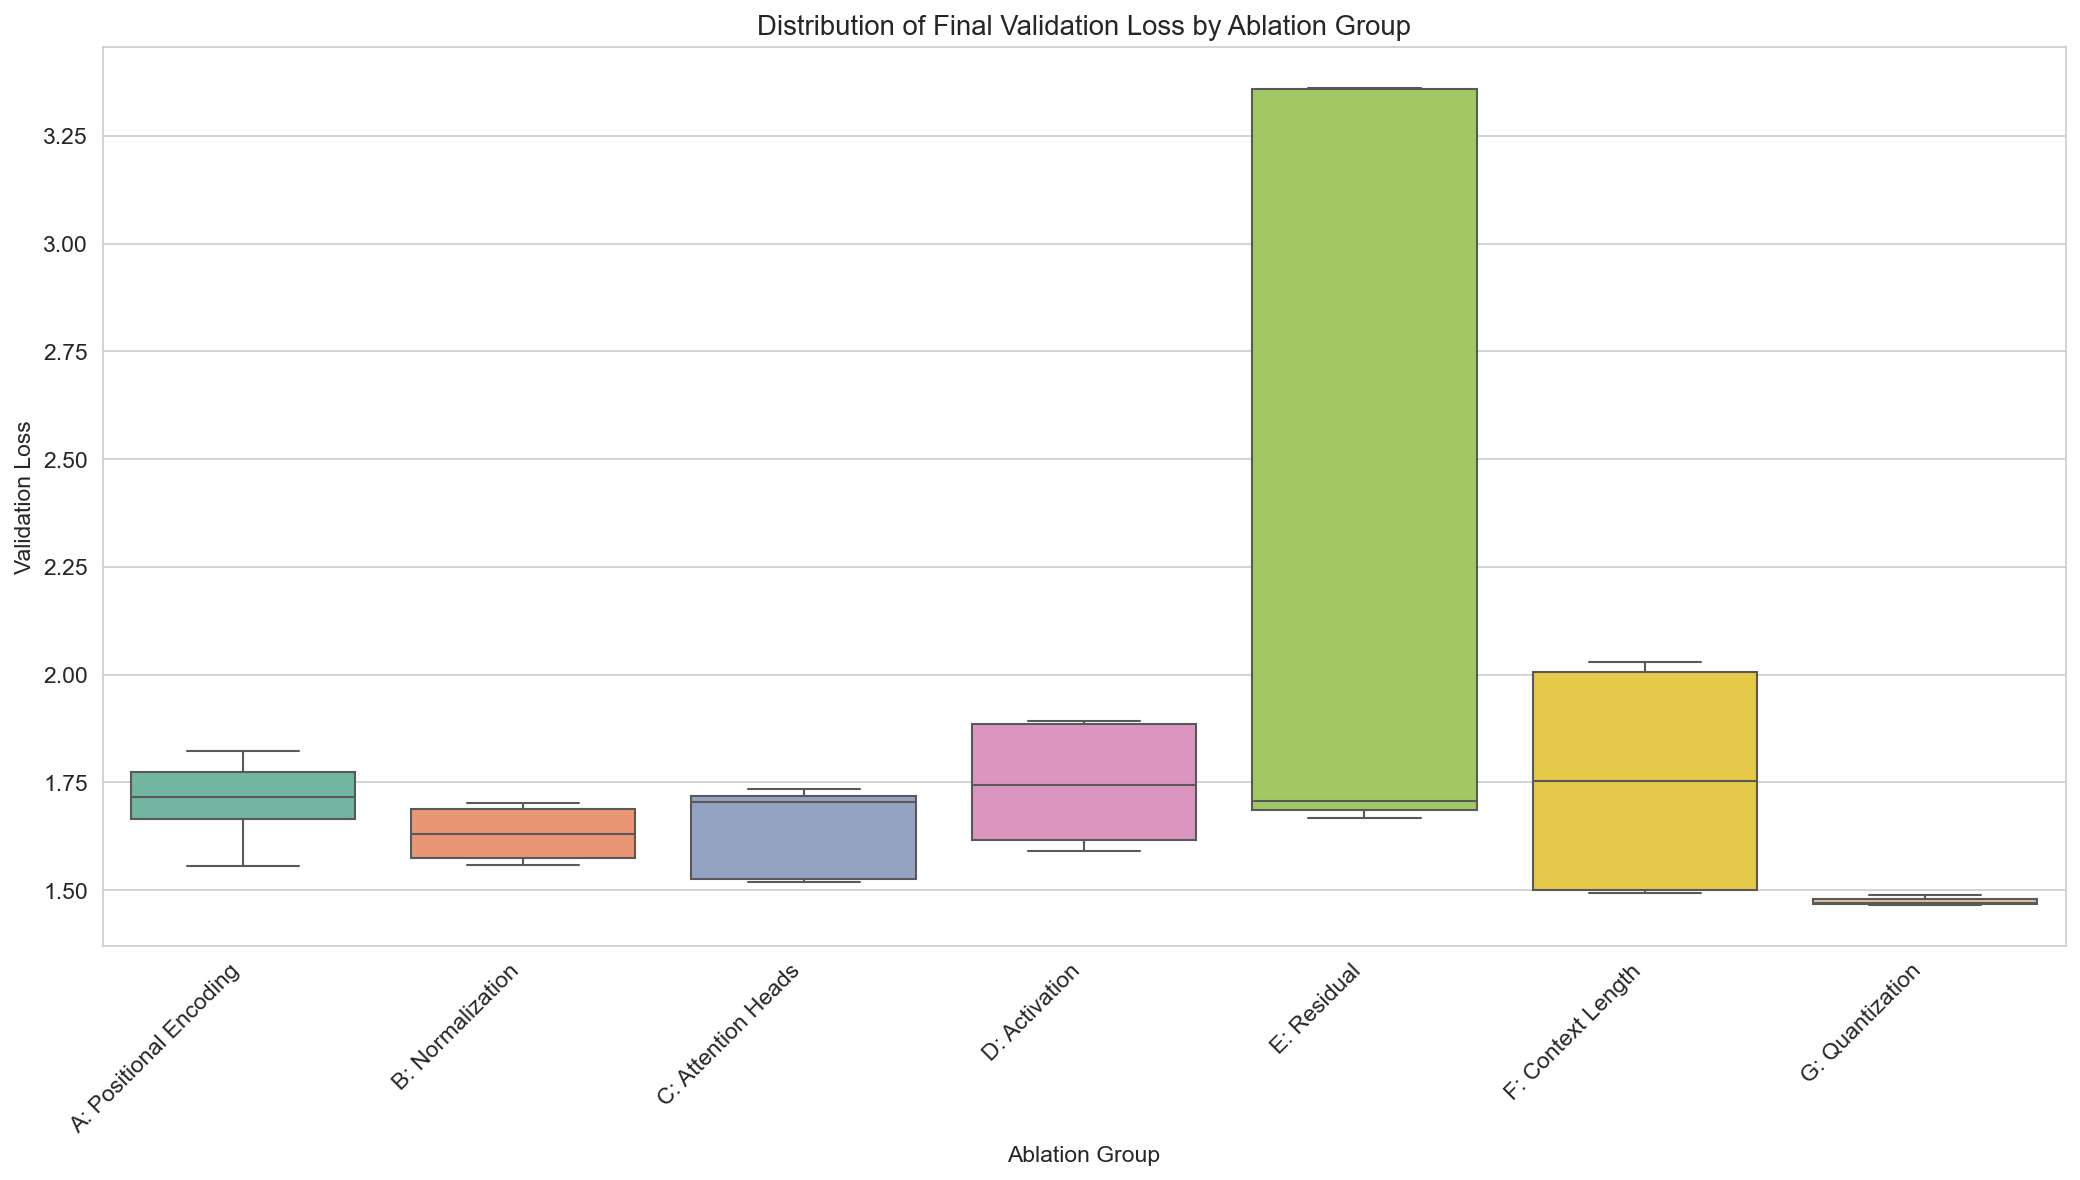

C:\Users\Rickey\AppData\Local\Temp\ipykernel_30036\2843594160.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='group', y='training_time_sec', palette='Set2', ax=ax_box2)


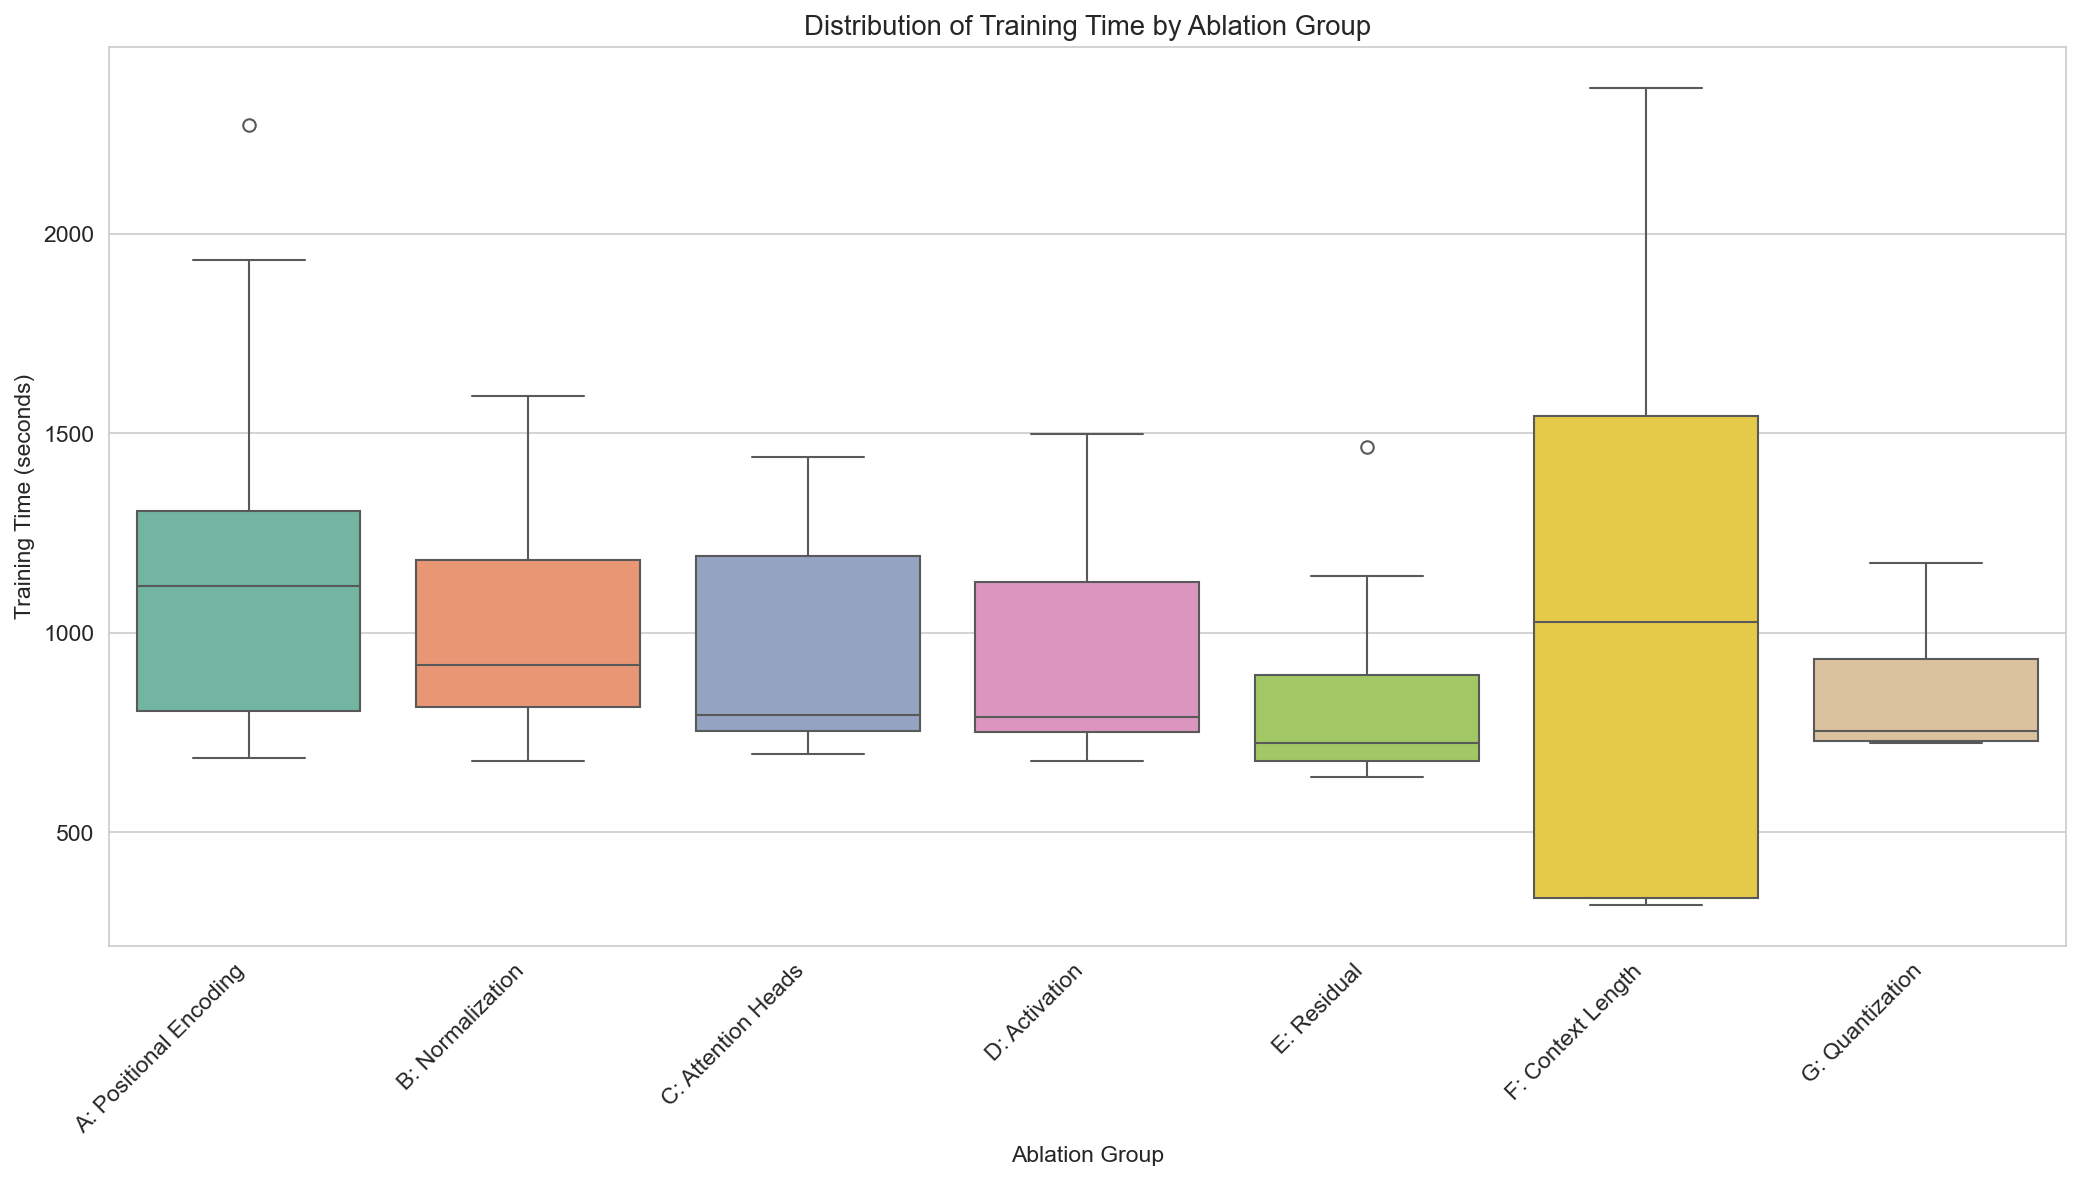


Found 92 history files. Performing convergence analysis...

=== Convergence analysis (average over seeds) ===
          run_name  best_val_loss   best_iter  final_val_loss
G1_ternary_weights       1.461392 4400.000000             NaN
           D1_relu       1.464403 1916.666667             NaN
    F1_context_128       1.468765 3000.000000             NaN
        C2_8_heads       1.469730 1833.333333             NaN
         C1_1_head       1.469743 2833.333333             NaN
E1_scaled_residual       1.470984 1791.666667             NaN
          baseline       1.471439 1708.333333             NaN
           A2_rope       1.471781 1458.333333             NaN
        B1_rmsnorm       1.473354 1791.666667             NaN
    F2_context_512       1.474781 1400.000000             NaN
       C3_12_heads       1.475238 1791.666667             NaN
        B2_post_ln       1.485574 2291.666667             NaN
          A3_alibi       1.492344 1333.333333             NaN
         D2_swiglu   

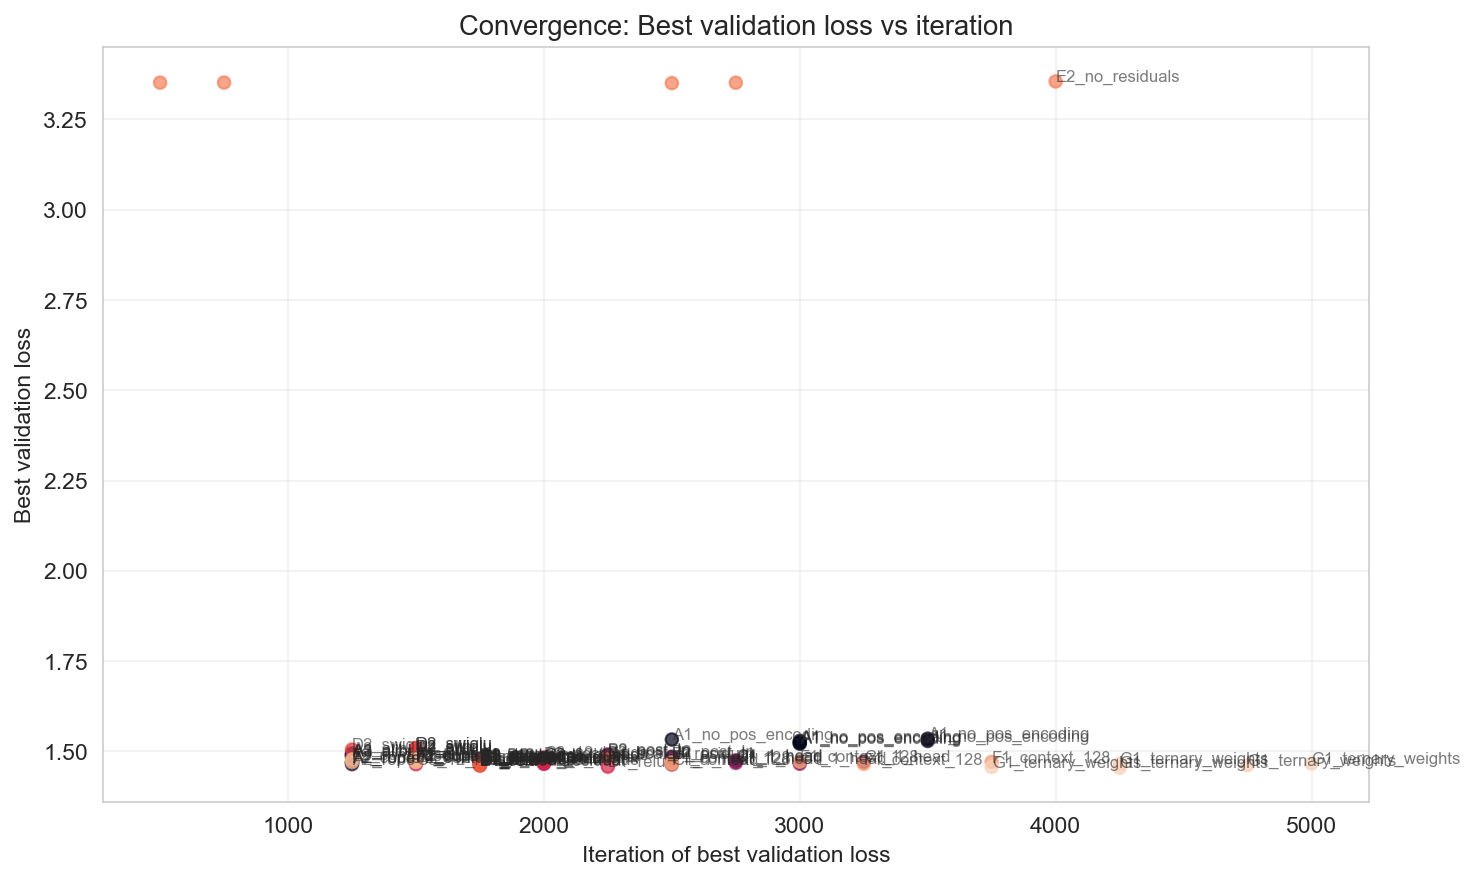

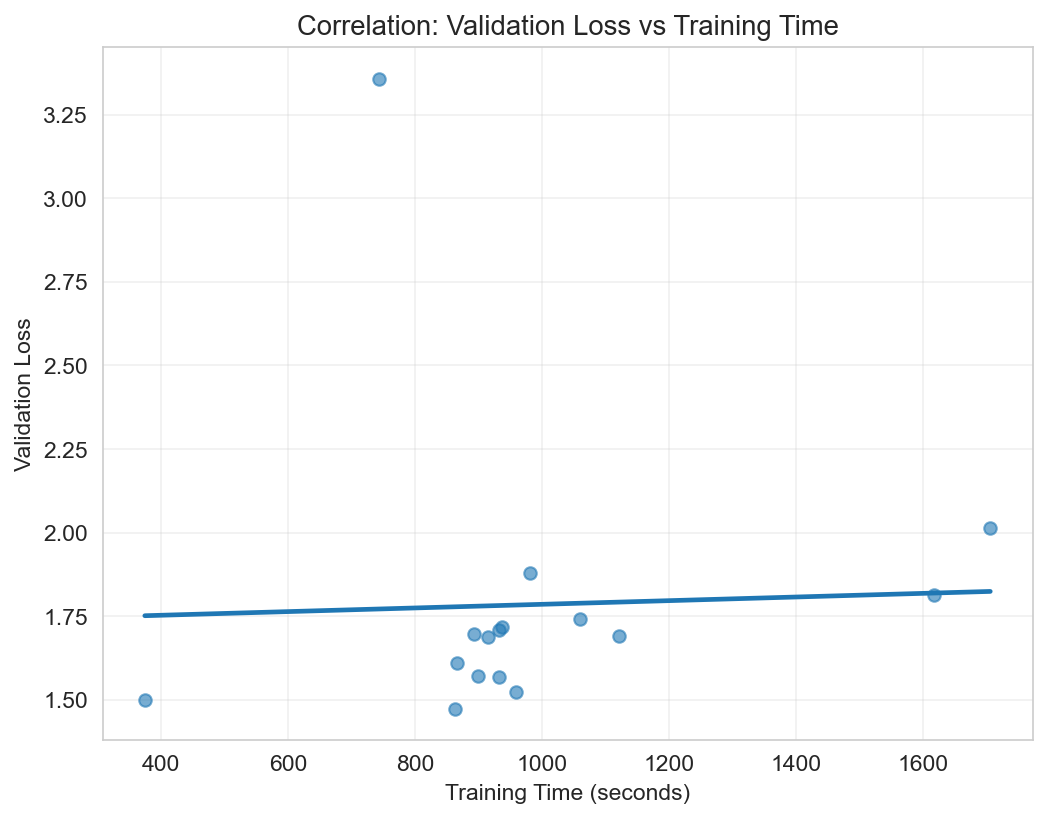


=== Seed variability (coefficient of variation) ===
          run_name  val_mean  val_std       cv
A1_no_pos_encoding  1.568687 0.017039 0.010862
E1_scaled_residual  1.688372 0.014340 0.008493
        C2_8_heads  1.710216 0.013897 0.008126
           A2_rope  1.743208 0.013791 0.007911
       C3_12_heads  1.718171 0.013383 0.007789
           D1_relu  1.609337 0.012513 0.007775
    F2_context_512  2.013404 0.012887 0.006401
G1_ternary_weights  1.473909 0.009180 0.006228
         D2_swiglu  1.880832 0.010888 0.005789
        B1_rmsnorm  1.691348 0.009659 0.005711

Detailed analysis complete. All outputs saved to analysis_figures


In [4]:
# ==================================================
# 9. Detailed Analysis of Summary Data and Histories
# ==================================================

print("\n" + "="*80)
print("DETAILED ANALYSIS OF SUMMARY DATA")
print("="*80)

# 9.1 Summary statistics for each run_name (raw, not averaged)
# Compute additional metrics: min, max, std for val/loss and training_time_sec across seeds
df_summary_stats = df_valid.groupby('run_name').agg({
    'val/loss': ['mean', 'std', 'min', 'max', 'count'],
    'training_time_sec': ['mean', 'std', 'min', 'max'],
    'n_params': 'first'
}).reset_index()
# Flatten column names
df_summary_stats.columns = ['run_name', 'val_mean', 'val_std', 'val_min', 'val_max', 'n_seeds',
                            'time_mean', 'time_std', 'time_min', 'time_max', 'n_params']
df_summary_stats.sort_values('val_mean', inplace=True)

print("\n=== Detailed statistics per configuration (across seeds) ===")
print(df_summary_stats[['run_name', 'val_mean', 'val_std', 'val_min', 'val_max', 'time_mean', 'time_std']].to_string(index=False))

# Save to CSV
df_summary_stats.to_csv(os.path.join(OUTPUT_DIR, 'detailed_summary_stats.csv'), index=False)

# 9.2 Box plots of validation loss per ablation group
# We need to map run_name to group and short name
df_valid['group'] = df_valid['run_name'].map(group_mapping)
df_valid['short_name'] = df_valid['run_name'].str.replace('_', ' ')
order_dict_flat = {}
for g, lst in order_dict.items():
    for name in lst:
        order_dict_flat[name] = g
df_valid['group_order'] = df_valid['run_name'].map(order_dict_flat)
# Sort groups alphabetically but keep baseline first within each group? We'll use group as hue.

fig_box, ax_box = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_valid, x='group', y='val/loss', palette='Set2', ax=ax_box)
ax_box.set_title('Distribution of Final Validation Loss by Ablation Group')
ax_box.set_xlabel('Ablation Group')
ax_box.set_ylabel('Validation Loss')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'val_loss_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 9.3 Box plot of training time
fig_box2, ax_box2 = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_valid, x='group', y='training_time_sec', palette='Set2', ax=ax_box2)
ax_box2.set_title('Distribution of Training Time by Ablation Group')
ax_box2.set_xlabel('Ablation Group')
ax_box2.set_ylabel('Training Time (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'time_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 9.4 Analyze historical data if available (convergence, final values, etc.)
history_files = [f for f in os.listdir(HISTORY_DIR) if f.endswith('_history.csv')]
if history_files:
    print(f"\nFound {len(history_files)} history files. Performing convergence analysis...")
    conv_data = []
    for file in history_files:
        full_path = os.path.join(HISTORY_DIR, file)
        # Extract run_name and run_id using a more robust method: load and check first rows? Better: use stored mapping.
        # We'll parse using the same method as before: match against known run_names
        name_part = file.replace('_history.csv', '')
        found_name = None
        for kn in df_valid['run_name'].unique():
            if name_part.startswith(kn):
                found_name = kn
                break
        if found_name is None:
            continue
        run_id = name_part[len(found_name)+1:] if len(name_part) > len(found_name) else ''
        hist = pd.read_csv(full_path)
        if 'val/loss' in hist.columns and 'iter' in hist.columns:
            # Find best validation loss and its iteration
            best_idx = hist['val/loss'].idxmin()
            best_loss = hist.loc[best_idx, 'val/loss']
            best_iter = hist.loc[best_idx, 'iter']
            final_loss = hist['val/loss'].iloc[-1] if len(hist) > 0 else np.nan
            # Also get final training loss
            final_train = hist['train/loss'].iloc[-1] if 'train/loss' in hist.columns and len(hist) > 0 else np.nan
            conv_data.append({
                'run_name': found_name,
                'run_id': run_id,
                'best_val_loss': best_loss,
                'best_iter': best_iter,
                'final_val_loss': final_loss,
                'final_train_loss': final_train
            })
    df_conv = pd.DataFrame(conv_data)
    if not df_conv.empty:
        # Add group info
        df_conv['group'] = df_conv['run_name'].map(group_mapping)
        # Average per run_name
        df_conv_avg = df_conv.groupby('run_name').agg({
            'best_val_loss': 'mean',
            'best_iter': 'mean',
            'final_val_loss': 'mean',
            'final_train_loss': 'mean'
        }).reset_index()
        df_conv_avg.sort_values('best_val_loss', inplace=True)
        print("\n=== Convergence analysis (average over seeds) ===")
        print(df_conv_avg[['run_name', 'best_val_loss', 'best_iter', 'final_val_loss']].to_string(index=False))
        # Save
        df_conv_avg.to_csv(os.path.join(OUTPUT_DIR, 'convergence_analysis.csv'), index=False)
        
        # Plot best iteration vs validation loss
        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(df_conv['best_iter'], df_conv['best_val_loss'], c=df_conv['run_name'].astype('category').cat.codes, alpha=0.7)
        plt.xlabel('Iteration of best validation loss')
        plt.ylabel('Best validation loss')
        plt.title('Convergence: Best validation loss vs iteration')
        plt.grid(True, alpha=0.3)
        # Add labels for some points
        for _, row in df_conv.iterrows():
            if row['best_val_loss'] < 1.6 or row['best_iter'] > 3000:
                plt.annotate(row['run_name'], (row['best_iter'], row['best_val_loss']), fontsize=8, alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'convergence_scatter.png'), dpi=300)
        plt.show()
    else:
        print("No valid convergence data extracted.")
else:
    print("\nNo history files found. Skipping convergence analysis.")

# 9.5 Correlation between validation loss and training time
plt.figure(figsize=(8, 6))
sns.regplot(data=df_mean, x='training_time_sec', y='val/loss', ci=None, scatter_kws={'alpha':0.6})
plt.xlabel('Training Time (seconds)')
plt.ylabel('Validation Loss')
plt.title('Correlation: Validation Loss vs Training Time')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_time_correlation.png'), dpi=300)
plt.show()

# 9.6 Seed variability analysis: compute coefficient of variation for each run_name
seed_var = df_valid.groupby('run_name').agg({
    'val/loss': ['mean', 'std']
}).reset_index()
seed_var.columns = ['run_name', 'val_mean', 'val_std']
seed_var['cv'] = seed_var['val_std'] / seed_var['val_mean']
seed_var.sort_values('cv', ascending=False, inplace=True)
print("\n=== Seed variability (coefficient of variation) ===")
print(seed_var[['run_name', 'val_mean', 'val_std', 'cv']].head(10).to_string(index=False))

print("\n" + "="*80)
print("Detailed analysis complete. All outputs saved to", OUTPUT_DIR)
print("="*80)

In [5]:
#!/usr/bin/env python
# coding: utf-8

"""
Generate high-quality figures for the final report.
Reads summary statistics and history data from analysis_figures/ and history_data/.
Saves figures to report_figures/.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ==================== CONFIGURATION ====================
OUTPUT_DIR = "report_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paths to existing data
SUMMARY_TABLE = "analysis_figures/summary_table.csv"
DETAILED_STATS = "analysis_figures/detailed_summary_stats.csv"
CONVERGENCE = "analysis_figures/convergence_analysis.csv"
HISTORY_DIR = "history_data"

# Plotting style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
# Use a colorblind-friendly palette
palette = sns.color_palette("colorblind", 16)

# ==================== LOAD DATA ====================
df_summary = pd.read_csv(SUMMARY_TABLE)
df_stats = pd.read_csv(DETAILED_STATS)
df_conv = pd.read_csv(CONVERGENCE)

# Map group names to order for plotting
group_order = ['A: Positional Encoding', 'B: Normalization', 'C: Attention Heads',
               'D: Activation', 'E: Residual', 'F: Context Length', 'G: Quantization']
df_stats['group'] = df_stats['run_name'].map(
    df_summary.set_index('Configuration')['Group'].to_dict()
)

# ==================== 1. Validation loss with error bars ====================
fig1, ax1 = plt.subplots(figsize=(12, 6))
# Sort by mean validation loss
df_stats_sorted = df_stats.sort_values('val_mean')
x = np.arange(len(df_stats_sorted))
bars = ax1.bar(x, df_stats_sorted['val_mean'], yerr=df_stats_sorted['val_std'],
               capsize=4, color=palette[0], edgecolor='black', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(df_stats_sorted['run_name'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Validation Loss')
ax1.set_title('Final Validation Loss (mean ± std over seeds)')
ax1.grid(axis='y', linestyle=':', alpha=0.6)
# Add value labels
for bar, val in zip(bars, df_stats_sorted['val_mean']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'validation_loss_all.pdf'))
plt.savefig(os.path.join(OUTPUT_DIR, 'validation_loss_all.png'))
plt.close()

# ==================== 2. Training time with error bars ====================
fig2, ax2 = plt.subplots(figsize=(12, 6))
df_stats_sorted_time = df_stats.sort_values('time_mean')
x = np.arange(len(df_stats_sorted_time))
bars = ax2.bar(x, df_stats_sorted_time['time_mean'], yerr=df_stats_sorted_time['time_std'],
               capsize=4, color=palette[1], edgecolor='black', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(df_stats_sorted_time['run_name'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title('Training Time (mean ± std over seeds)')
ax2.grid(axis='y', linestyle=':', alpha=0.6)
for bar, val in zip(bars, df_stats_sorted_time['time_mean']):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             f'{val:.0f}s', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_time_all.pdf'))
plt.savefig(os.path.join(OUTPUT_DIR, 'training_time_all.png'))
plt.close()

# ==================== 3. Scatter: Validation loss vs Training time ====================
fig3, ax3 = plt.subplots(figsize=(10, 7))
scatter = ax3.scatter(df_stats['time_mean'], df_stats['val_mean'],
                      c=df_stats['val_std'], s=100, cmap='viridis', edgecolors='black', alpha=0.8)
# Add labels
for _, row in df_stats.iterrows():
    ax3.annotate(row['run_name'], (row['time_mean'], row['val_mean']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_ylabel('Validation Loss')
ax3.set_title('Performance vs. Efficiency Trade-off')
cbar = plt.colorbar(scatter)
cbar.set_label('Standard Deviation of Validation Loss')
ax3.grid(True, linestyle=':', alpha=0.6)
# Highlight baseline
baseline_row = df_stats[df_stats['run_name'] == 'baseline']
ax3.scatter(baseline_row['time_mean'], baseline_row['val_mean'],
            s=150, facecolors='none', edgecolors='red', linewidth=2, label='baseline')
ax3.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_vs_time_scatter.pdf'))
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_vs_time_scatter.png'))
plt.close()

# ==================== 4. Convergence analysis ====================
if not df_conv.empty:
    fig4, ax4 = plt.subplots(figsize=(10, 7))
    # Merge with std for bubble size
    df_conv_merged = df_conv.merge(df_stats[['run_name', 'val_std']], on='run_name', how='left')
    scatter = ax4.scatter(df_conv_merged['best_iter'], df_conv_merged['best_val_loss'],
                          s=df_conv_merged['val_std']*500, alpha=0.6,
                          c=range(len(df_conv_merged)), cmap='tab20', edgecolors='black')
    for _, row in df_conv_merged.iterrows():
        ax4.annotate(row['run_name'], (row['best_iter'], row['best_val_loss']),
                     xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
    ax4.set_xlabel('Iteration of Best Validation Loss')
    ax4.set_ylabel('Best Validation Loss')
    ax4.set_title('Convergence Speed vs. Best Performance (bubble size = std)')
    ax4.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'convergence_analysis.pdf'))
    plt.savefig(os.path.join(OUTPUT_DIR, 'convergence_analysis.png'))
    plt.close()

# ==================== 5. Key learning curves ====================
key_runs = ['baseline', 'A1_no_pos_encoding', 'E2_no_residuals', 'G1_ternary_weights']
colors = {'baseline': 'blue', 'A1_no_pos_encoding': 'orange',
          'E2_no_residuals': 'red', 'G1_ternary_weights': 'green'}
fig5, ax5 = plt.subplots(figsize=(12, 6))
for run_name in key_runs:
    # Find the first history file for this run_name (any seed)
    import glob
    pattern = os.path.join(HISTORY_DIR, f"{run_name}_*_history.csv")
    files = glob.glob(pattern)
    if files:
        hist = pd.read_csv(files[0])
        if 'val/loss' in hist.columns and 'iter' in hist.columns:
            valid = hist['val/loss'].notna() & hist['iter'].notna()
            ax5.plot(hist.loc[valid, 'iter'], hist.loc[valid, 'val/loss'],
                     label=run_name, color=colors.get(run_name, 'black'), linewidth=1.5)
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Validation Loss')
ax5.set_title('Validation Loss Curves for Key Ablations')
ax5.legend()
ax5.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_key.pdf'))
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_key.png'))
plt.close()

# ==================== 6. Boxplot of validation loss by group ====================
# We need the raw df_valid to create boxplots. If not available, skip.
try:
    # Attempt to load the raw valid runs (we saved it in the notebook environment)
    # Since we don't have it here, we can generate a boxplot from the stats
    # But better: if df_valid is not in memory, we can recreate from summary stats?
    # Actually boxplot requires individual data points. We don't have that in CSV.
    # Instead, we can simulate with the mean and std? Not accurate.
    # Let's create a grouped bar chart with error bars instead.
    fig6, ax6 = plt.subplots(figsize=(12, 6))
    # Group by group, then plot mean and std
    grouped = df_stats.groupby('group').agg({'val_mean': 'mean', 'val_std': 'mean'}).reset_index()
    # Reorder groups
    grouped['group'] = pd.Categorical(grouped['group'], categories=group_order, ordered=True)
    grouped = grouped.sort_values('group')
    x = np.arange(len(grouped))
    bars = ax6.bar(x, grouped['val_mean'], yerr=grouped['val_std'], capsize=4,
                   color=palette[2], edgecolor='black', alpha=0.8)
    ax6.set_xticks(x)
    ax6.set_xticklabels(grouped['group'], rotation=45, ha='right')
    ax6.set_ylabel('Validation Loss')
    ax6.set_title('Validation Loss by Ablation Group (mean ± std)')
    ax6.grid(axis='y', linestyle=':', alpha=0.6)
    for bar, val in zip(bars, grouped['val_mean']):
        ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'val_loss_by_group.pdf'))
    plt.savefig(os.path.join(OUTPUT_DIR, 'val_loss_by_group.png'))
    plt.close()
except Exception as e:
    print(f"Could not create group boxplot: {e}")

# ==================== 7. Seed variability (horizontal bar) ====================
fig7, ax7 = plt.subplots(figsize=(10, 8))
df_variability = df_stats[['run_name', 'val_mean', 'val_std']].copy()
df_variability = df_variability.sort_values('val_mean')
y_pos = np.arange(len(df_variability))
ax7.errorbar(df_variability['val_mean'], y_pos, xerr=df_variability['val_std'],
             fmt='o', capsize=4, color='steelblue', ecolor='gray', elinewidth=2, markersize=8)
ax7.set_yticks(y_pos)
ax7.set_yticklabels(df_variability['run_name'])
ax7.set_xlabel('Validation Loss')
ax7.set_title('Seed Variability: Mean Validation Loss with Standard Deviation')
ax7.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'seed_variability.pdf'))
plt.savefig(os.path.join(OUTPUT_DIR, 'seed_variability.png'))
plt.close()

print(f"All report figures saved to {OUTPUT_DIR}/")

All report figures saved to report_figures/


1. validation_loss_all.pdf/png
Final validation loss with error bars
This bar chart shows the mean validation loss for every configuration (e.g., baseline, G1_ternary_weights, F1_context_128, etc.) averaged over multiple random seeds. The error bars represent the standard deviation across seeds, indicating the stability of each configuration. Lower loss is better. The chart helps identify which modifications significantly improve or degrade performance compared to the baseline.

2. training_time_all.pdf/png
Training time with error bars
Similar to the validation loss plot, this bar chart displays the mean training time (in seconds) for each configuration, again with standard deviation across seeds. It quantifies the computational cost of each ablation, allowing a direct comparison of efficiency. Faster (shorter) training times are preferable when resources are limited.

3. loss_vs_time_scatter.pdf/png
Performance vs. efficiency trade‑off
This scatter plot places each configuration in a 2D space where the x‑axis is training time and the y‑axis is validation loss. The colour of each point encodes the standard deviation of the validation loss (seed variability). The baseline is highlighted with a red circle. The plot reveals which configurations achieve low loss with short training time (the lower‑left region, e.g., F1_context_128 and G1_ternary_weights) and which are Pareto‑inefficient (e.g., F2_context_512, which is both slow and poor).

4. convergence_analysis.pdf/png
Convergence speed vs. best performance
If convergence data are available (i.e., the iteration at which the validation loss reached its minimum), this plot shows the best validation loss achieved against the iteration number where that minimum occurred. The bubble size is proportional to the standard deviation of the validation loss (seed variability). Smaller bubbles indicate more consistent convergence. The figure helps understand whether a configuration converges quickly (left side) or needs many iterations to reach its optimum (right side).

5. learning_curves_key.pdf/png
Validation loss curves for key ablations
This line plot traces the validation loss over the whole training process for four representative configurations: baseline, A1_no_pos_encoding (no positional encoding), E2_no_residuals (no residual connections), and G1_ternary_weights (ternary quantization). It illustrates how each model learns over time—for instance, E2_no_residuals barely improves, while G1_ternary_weights gradually reaches a low loss.

6. val_loss_by_group.pdf/png
Validation loss aggregated by ablation group
The configurations are grouped by the ablated component (Positional Encoding, Normalization, Attention Heads, Activation, Residual, Context Length, Quantization). For each group, the mean validation loss (averaged over all configurations in that group) is shown with error bars that reflect the average standard deviation within the group. This gives a high‑level view of which architectural axis has the largest impact on performance.

7. seed_variability.pdf/png
Seed variability – mean validation loss with error bars
This horizontal bar chart lists each configuration on the y‑axis and its mean validation loss on the x‑axis, with horizontal error bars representing the standard deviation across seeds. Configurations with longer error bars are more sensitive to the random seed, making their results less reproducible. The chart highlights, for example, that A1_no_pos_encoding exhibits relatively high variability, whereas G1_ternary_weights and baseline are very stable.

